# 쿨링 샴푸 리뷰 텍스트 분석

앞선 노트북에서는 `쿨링 샴푸` 시장을 상품 구조와 리뷰 정량 지표로 살펴봤습니다.  
이번에는 리뷰 본문 안으로 들어가 소비자가 실제로 어떤 단어로 만족과 불안을 표현하는지 확인합니다.

처음 가설은 단순했습니다.  
<b>“여름이면 쿨링 샴푸를 더 많이 찾을 것이다.”</b>

하지만 리뷰를 읽어보니 질문은 조금 바뀌었습니다. 소비자는 쿨링감을 원하지만, 동시에 너무 강한 쿨링이 <b>자극</b>, <b>건조함</b>, <b>두피 민감 반응</b>으로 이어질까 봐 조심하고 있었습니다. 일부 리뷰에서는 시원함이 오래 가지 않거나 기대보다 약하다는 반응도 확인됐습니다.

그래서 이 노트북의 핵심 질문은 아래처럼 정리했습니다.

> <b>쿨링을 원하는 소비자는 무엇 때문에 구매를 망설이고, 어떤 메시지에 설득될까?</b>


## 현재 노트북의 범위

전체 프로젝트 중 이 노트북은 리뷰 본문을 직접 다루는 텍스트 분석 파트입니다.  
단순히 자주 나온 단어를 세는 데서 끝내지 않고, <b>구매 장벽과 마케팅 메시지</b>로 연결하는 데 초점을 둡니다.

- <b>6-2. 리뷰 텍스트 분석</b>
  - 텍스트 전처리
  - 전체 키워드 확인
  - 브랜드/평점/관심도별 키워드 비교
  - 긍정/부정 신호와 핵심 경험 주제 분석
  - 리뷰 클러스터링을 통한 페르소나 도출
- <b>7-1. 리뷰 분석 인사이트</b>
  - 상품 메시지와 리뷰 반응 비교
  - 메시지 우선순위와 페르소나별 실행안 정리
  - 다음 통합 인사이트 분석으로 넘길 질문 정리


## 데이터 설명

이번 분석에는 `03_review_analysis.ipynb`에서 전처리 후 저장한 정제 리뷰 데이터를 사용합니다.  
03번에서 중복 제거, 가격대 생성, 옵션혜택 분리, 도움돼요구간화, 리뷰 길이 계산까지 끝냈기 때문에 여기서는 리뷰 본문 텍스트에 집중합니다.

- <b>입력 데이터</b>: `data/oliveyoung_cooling_shampoo_reviews_cleaned.csv`
- <b>분석 단위</b>: 리뷰 1개 = 1행
- <b>리뷰 수</b>: 644건
- <b>주요 컬럼</b>: `브랜드`, `상품명`, `가격대`, `옵션명`, `옵션혜택`, `리뷰내용`, `리뷰평점`, `도움돼요구간`, `사진여부`, `리뷰글자수`, `리뷰단어수`
- <b>주의</b>: `도움돼요수` 원본 숫자는 정제 데이터에 포함하지 않았으므로, 이 노트북에서는 `도움돼요구간`을 기준으로 관심도 수준을 비교합니다.

### 컬럼 메모

주요 분석 컬럼은 <b>굵게</b> 표시했습니다.

- <b>`리뷰내용`</b>: 소비자가 작성한 리뷰 본문 텍스트
- <b>`리뷰평점`</b>: 소비자가 부여한 리뷰 평점
- <b>`도움돼요구간`</b>: 도움돼요 반응을 구간화한 관심도 수준
- <b>`가격대`</b>: 가격을 구간화한 값
- <b>`옵션명`</b>: 리뷰가 작성된 상품 옵션명
- <b>`옵션혜택`</b>: 옵션명에서 분리한 기획, 증정, 단품 등 혜택 구분
- <b>`브랜드`</b>, <b>`상품명`</b>: 리뷰가 연결된 상품 정보
- `사진여부`, `리뷰글자수`, `리뷰단어수`: 리뷰의 작성 형태와 깊이를 보는 보조 지표


## 1. 라이브러리 불러오기

텍스트 정제, 키워드 빈도, 워드클라우드, TF-IDF 벡터화, KMeans 클러스터링에 필요한 라이브러리를 불러옵니다.


In [1]:
# 데이터 처리
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from wordcloud import WordCloud
import networkx as nx

# 텍스트 벡터화/클러스터링
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

# pandas 정규식 그룹 안내 경고는 출력 가독성을 위해 숨깁니다.
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression.*")


In [2]:
# 출력 옵션 설정
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)


In [3]:
# 한글 폰트 설정
FONT_PATH = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
FONT_PROP = fm.FontProperties(fname=FONT_PATH)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic", rc={"axes.unicode_minus": False})


## 2. 정제 데이터 불러오기

03번 노트북에서 저장한 정제 리뷰 데이터를 불러옵니다.  
이 노트북은 원천 데이터 재전처리보다, 정제된 리뷰 본문을 활용한 텍스트 분석에 집중합니다.


In [4]:
# 정제된 리뷰 데이터 불러오기
cleaned_review_path = "data/oliveyoung_cooling_shampoo_reviews_cleaned.csv"
review_data = pd.read_csv(cleaned_review_path)

load_summary = pd.DataFrame({
    "항목": ["리뷰 수", "컬럼 수"],
    "값": review_data.shape,
})

display(load_summary)

review_data.assign(
    상품명요약=review_data["상품명"].str.slice(0, 34) + "...",
    리뷰요약=review_data["리뷰내용"].str.slice(0, 60) + "...",
)[["브랜드", "상품명요약", "가격대", "옵션명", "리뷰평점", "도움돼요구간", "리뷰요약"]].head(5)


,항목,값
0,리뷰 수,644
1,컬럼 수,12


,브랜드,상품명요약,가격대,옵션명,리뷰평점,도움돼요구간,리뷰요약
0,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레...,1만원 미만,쿨링,5,매우 높음,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다...
1,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레...,1만원 미만,쿨링,5,매우 높음,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확..."
2,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레...,1만원 미만,레몬,5,매우 높음,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너...
3,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레...,1만원 미만,쿨링,5,매우 높음,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요....
4,온더바디,온더바디 발을씻자 코튼 풋샴푸 리필 500ml 4종 택1 (레...,1만원 미만,레몬,5,매우 높음,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사...


## 3. 정제 데이터 확인

텍스트 분석에 들어가기 전, 정제 데이터가 의도한 형태인지 확인합니다.  
여기서는 필요한 컬럼이 모두 있는지 점검하고, 이후 비교에 쓰기 쉽도록 `도움돼요구간`을 순서형 점수로 변환합니다.


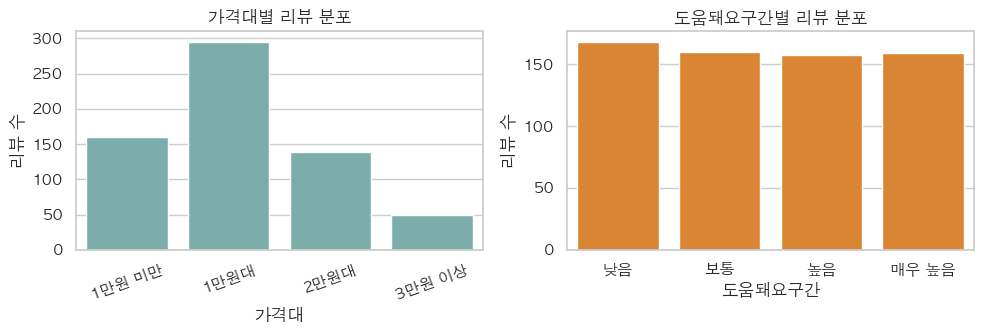

,항목,값
0,분석 리뷰 수,644.00
1,브랜드 수,26.00
2,상품 수,38.00
3,가격대 수,4.00
4,도움돼요구간 수,4.00
5,리뷰내용 결측 수,0.00
6,평균 리뷰 글자 수,156.40


In [5]:
# 정제 데이터 분석 준비
required_cols = [
    "브랜드", "상품명", "가격", "가격대", "옵션명", "옵션혜택",
    "리뷰내용", "리뷰평점", "도움돼요구간", "사진여부", "리뷰글자수", "리뷰단어수"
]

missing_cols = [col for col in required_cols if col not in review_data.columns]
if missing_cols:
    raise ValueError(f"정제 데이터에 필요한 컬럼이 없습니다: {missing_cols}")

# 기본 타입 정리
review_data["리뷰내용"] = review_data["리뷰내용"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
review_data["리뷰평점"] = pd.to_numeric(review_data["리뷰평점"], errors="coerce")
review_data["가격"] = pd.to_numeric(review_data["가격"], errors="coerce")
review_data["리뷰글자수"] = pd.to_numeric(review_data["리뷰글자수"], errors="coerce")
review_data["리뷰단어수"] = pd.to_numeric(review_data["리뷰단어수"], errors="coerce")

# 구간형 컬럼 순서 고정
price_order = ["1만원 미만", "1만원대", "2만원대", "3만원 이상"]
help_order = ["낮음", "보통", "높음", "매우 높음"]
review_data["가격대"] = pd.Categorical(review_data["가격대"], categories=price_order, ordered=True)
review_data["도움돼요구간"] = pd.Categorical(review_data["도움돼요구간"], categories=help_order, ordered=True)

# 도움돼요구간을 관심도 점수로 변환합니다. 숫자가 클수록 더 높은 도움돼요구간입니다.
help_score_map = {"낮음": 1, "보통": 2, "높음": 3, "매우 높음": 4}
review_data["도움돼요점수"] = review_data["도움돼요구간"].astype(str).map(help_score_map)

cleaned_data_summary = pd.DataFrame({
    "항목": ["분석 리뷰 수", "브랜드 수", "상품 수", "가격대 수", "도움돼요구간 수", "리뷰내용 결측 수", "평균 리뷰 글자 수"],
    "값": [
        len(review_data),
        review_data["브랜드"].nunique(),
        review_data["상품명"].nunique(),
        review_data["가격대"].nunique(),
        review_data["도움돼요구간"].nunique(),
        review_data["리뷰내용"].isna().sum(),
        round(review_data["리뷰글자수"].mean(), 1),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
sns.countplot(data=review_data, x="가격대", order=price_order, color="#72B7B2", ax=axes[0])
axes[0].set_title("가격대별 리뷰 분포")
axes[0].set_xlabel("가격대")
axes[0].set_ylabel("리뷰 수")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=review_data, x="도움돼요구간", order=help_order, color="#F58518", ax=axes[1])
axes[1].set_title("도움돼요구간별 리뷰 분포")
axes[1].set_xlabel("도움돼요구간")
axes[1].set_ylabel("리뷰 수")
plt.tight_layout()
plt.show()

cleaned_data_summary


<b>정제 리뷰 데이터에서 확인한 점</b>

분석 대상은 총 <b>644건</b>입니다. 리뷰는 <b>1만원대(295건)</b>에 가장 많이 몰려 있고, 도움돼요구간은 `낮음~매우 높음`이 비교적 고르게 나뉘어 있습니다.

따라서 이후 분석에서는 아래 두 가지를 중심으로 읽습니다.

- 가격 커뮤니케이션은 `1만원대 중심의 대중 가격대`를 기본선으로 본다.
- 도움돼요가 높은 리뷰만 따로 보기보다, 관심도 구간별로 어떤 표현이 달라지는지 비교한다.


## 6-2. 리뷰 텍스트 분석

리뷰 본문을 단어 단위로 정리해 소비자가 반복적으로 언급한 경험을 확인합니다.

분석 흐름은 가볍게 보면 아래 순서입니다.

1. <b>전체 단어</b>로 소비자가 많이 말한 경험을 확인합니다.
2. <b>브랜드/평점/도움돼요구간</b>별로 단어 차이를 비교합니다.
3. <b>긍정/부정 신호</b>로 만족 포인트와 구매 장벽을 나눕니다.
4. <b>클러스터링</b>으로 리뷰를 페르소나처럼 읽을 수 있게 묶습니다.


### 6-2-1. 텍스트 전처리

리뷰 본문에서 특수문자와 불필요한 표현을 정리하고, 키워드 추출용 토큰을 만듭니다.  
여기서의 전처리는 복잡한 자연어 처리 모델링보다, <b>리뷰에서 반복되는 사용 경험을 일관된 기준으로 비교하기 위한 키워드 정리</b>에 가깝습니다.


In [6]:
# 리뷰 텍스트 정제 함수
# 한글/영문/숫자만 남기고 반복 공백을 정리합니다.
def clean_review_text(text):
    text = str(text).lower()
    text = re.sub(r"[^0-9a-zA-Z가-힣\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

review_data["정제리뷰"] = review_data["리뷰내용"].apply(clean_review_text)
review_data.assign(
    리뷰요약=review_data["리뷰내용"].str.slice(0, 70) + "...",
    정제요약=review_data["정제리뷰"].str.slice(0, 70) + "...",
)[["리뷰요약", "정제요약"]].head(5)


,리뷰요약,정제요약
0,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다...,곰팡이까지 없애주는 발을 씻자 떨어지면 무조건 쟁여야 합니다...
1,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습...",여름 대비 필수템입니다 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다...
2,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성...,사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 ...
3,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요....,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요 시원해요...
4,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다! 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 ...,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다 발체취가 완전 줄고 칙칙 뿌려서 사용하는 거다보니까 너...


In [7]:
# 불용어 설정
# 의미 보존을 위해 핵심 주제어는 별도 사전 분석에서 다시 다룹니다.
stopwords = {
    "그리고", "그래서", "하지만", "근데", "그냥", "정말", "진짜", "너무", "아주", "많이", "약간",
    "조금", "계속", "항상", "이번", "처음", "다시", "바로", "완전", "엄청", "제일", "거의",
    "있는", "없는", "같아요", "같습니다", "같고", "같은", "하면", "해서", "하고", "하면", "했는데",
    "합니다", "했어요", "되어", "되는", "되서", "쓰기", "사용", "사용감", "사용해", "사용하고", "사용하면",
    "구매", "구매했어요", "샀어요", "사서", "제품", "상품", "리뷰", "올리브영", "올영", "추천", "합니다",
    "샴푸", "쿨링", "쿨링감", "좋아요", "좋습니다", "좋네요", "좋고", "좋은", "좋아서", "좋더라구요",
    "있어요", "있습니다", "없어요", "없습니다", "느낌", "느낌이", "때문에", "정도", "편이에요",
    "머리", "두피", "향", "가격", "구성", "자극", "시원", "시원해요", "시원합니다",
}

focus_terms = ["쿨링", "쿨링감", "시원", "향", "두피", "자극", "가격", "구성"]

suffix_patterns = [
    r"입니다$", r"합니다$", r"했어요$", r"해요$", r"어요$", r"아요$", r"네요$", r"더라구요$",
    r"습니다$", r"네요$", r"는데$", r"고요$", r"구요$", r"으로$", r"에서$", r"에게$", r"까지$",
    r"부터$", r"보다$", r"처럼$", r"이라$", r"라서$", r"이라서$", r"하고$", r"하고$", r"하면$",
    r"은$", r"는$", r"이$", r"가$", r"을$", r"를$", r"도$", r"에$", r"의$", r"로$", r"와$", r"과$",
]

def normalize_token(token):
    token = token.strip().lower()
    for pattern in suffix_patterns:
        token = re.sub(pattern, "", token)
    return token

def tokenize_review(text, min_len=2, keep_focus=False):
    raw_tokens = re.findall(r"[0-9a-zA-Z가-힣]+", str(text).lower())
    tokens = []
    for token in raw_tokens:
        token = normalize_token(token)
        if len(token) < min_len:
            continue
        if token in stopwords and not keep_focus:
            continue
        if re.fullmatch(r"\d+", token):
            continue
        tokens.append(token)
    return tokens

review_data["키워드토큰"] = review_data["정제리뷰"].apply(tokenize_review)
review_data["토큰문서"] = review_data["키워드토큰"].apply(lambda tokens: " ".join(tokens))

review_data.assign(
    리뷰요약=review_data["정제리뷰"].str.slice(0, 60) + "...",
    토큰샘플=review_data["키워드토큰"].apply(lambda tokens: tokens[:8]),
)[["리뷰요약", "토큰샘플"]].head(5)


,리뷰요약,토큰샘플
0,곰팡이까지 없애주는 발을 씻자 떨어지면 무조건 쟁여야 합니다...,"[곰팡, 없애주, 씻자, 떨어지면, 무조건, 쟁여야]"
1,여름 대비 필수템입니다 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데 사용해보니 일반 바디워시와는 확실히...,"[여름, 대비, 필수템, 전용, 세정제라, 필요할까, 싶었, 사용해보니]"
2,사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 ...,"[분사하자마자, 상큼달달한, 자몽껌, 화장실, 퍼집니다, 인위적이지, 않아서, 때마다]"
3,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요 시원해요...,"[비누체, 하기, 귀찮아서, 스프레이, 보드리면, 간편해서]"
4,다른 향들 전부 사용해봤는데 뭐니뭐니해도 오리지널이 최고인 것 같습니다 발체취가 완전 줄고 칙칙 뿌려서 사용...,"[다른, 향들, 전부, 사용해봤, 뭐니뭐니해, 오리지널, 최고인, 발체취]"


In [8]:
# 전처리 결과 요약
text_preprocessing_summary = pd.DataFrame({
    "항목": ["분석 리뷰 수", "평균 원문 글자 수", "평균 토큰 수", "고유 토큰 수", "빈 토큰 리뷰 수"],
    "값": [
        len(review_data),
        round(review_data["리뷰글자수"].mean(), 1),
        round(review_data["키워드토큰"].str.len().mean(), 1),
        len(set(token for tokens in review_data["키워드토큰"] for token in tokens)),
        (review_data["키워드토큰"].str.len() == 0).sum(),
    ],
})

text_preprocessing_summary


,항목,값
0,분석 리뷰 수,644.00
1,평균 원문 글자 수,156.40
2,평균 토큰 수,24.20
3,고유 토큰 수,"6,450.00"
4,빈 토큰 리뷰 수,0.00


### 6-2-2. 전체 키워드 확인

전체 리뷰에서 자주 등장한 키워드를 빈도순으로 확인하고, 워드클라우드로 시각화합니다.  
단어가 겹치지 않도록 배치해 어떤 사용 경험이 크게 반복되는지 읽기 쉽게 확인합니다.


In [9]:
# 전체 키워드 빈도 생성
keyword_noise_words = {
    "않고", "있어서", "나서", "생각", "좋았", "쓰고", "다른", "특히", "일단", "이거",
    "이건", "그래", "때문", "분들", "사용할", "사용해", "구매했", "원래", "없이", "살짝", "않아서", "없고", "없어서", "아니라", "알아서", "있었", "쓰면", "한번", "하나",
}
all_tokens = [
    token
    for tokens in review_data["키워드토큰"]
    for token in tokens
    if token not in keyword_noise_words
]
keyword_counter = Counter(all_tokens)
keyword_freq = pd.DataFrame(keyword_counter.most_common(50), columns=["키워드", "빈도"])


#### 워드클라우드 확인

전체 리뷰에서 반복적으로 등장한 키워드를 워드클라우드로 확인합니다.


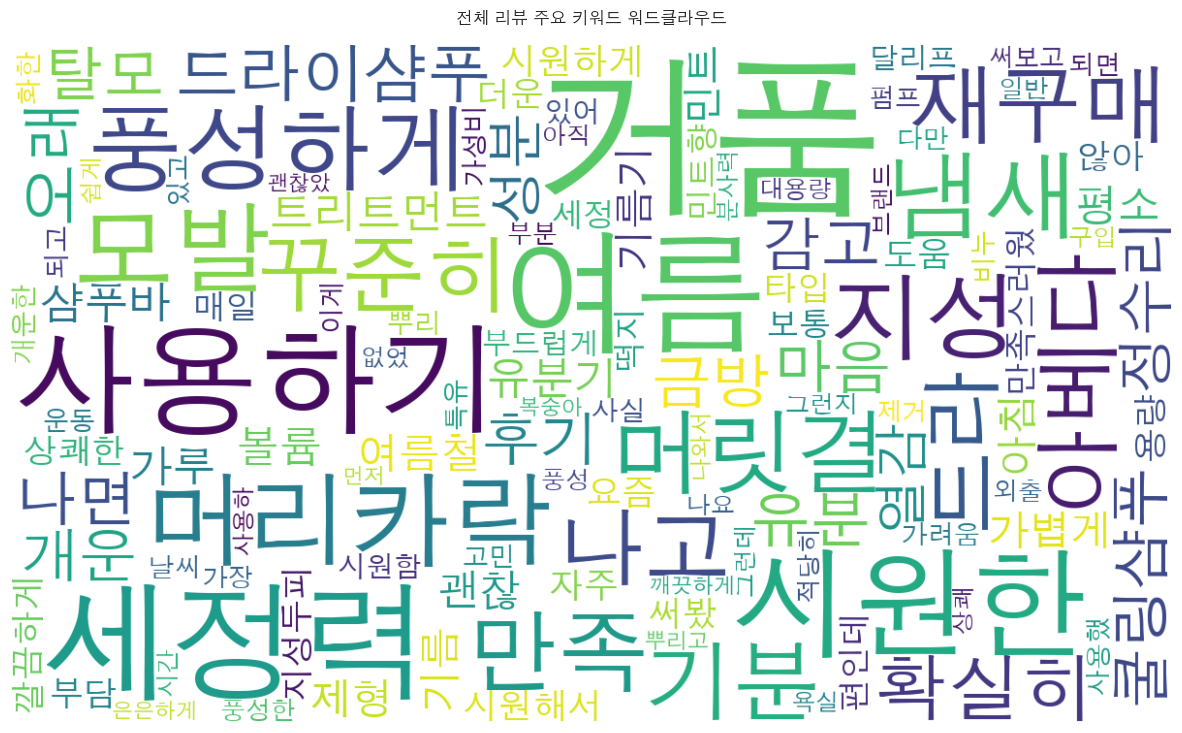

,키워드,빈도
0,거품,273
1,여름,119
2,세정력,111
3,사용하기,90
4,시원한,89
5,머리카락,57
6,모발,53
7,냄새,49
8,풍성하게,47
9,지성,47


In [10]:
# 전체 리뷰 주요 키워드 워드클라우드
wordcloud = WordCloud(
    font_path=FONT_PATH,
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=120,
    max_font_size=180,
    relative_scaling=0.4,
    prefer_horizontal=0.85,
    collocations=False,
    random_state=42,
).generate_from_frequencies(keyword_counter)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("전체 리뷰 주요 키워드 워드클라우드", pad=16)
plt.show()

keyword_freq.head(20)


<b>전체 키워드에서 확인한 점</b>

워드클라우드는 전체 리뷰에서 반복적으로 등장한 단어를 크게 보여줍니다. 글자가 클수록 소비자가 더 자주 말한 표현입니다.

상위 키워드는 `거품`, `여름`, `세정력`, `사용하기`, `시원한`으로 나타났습니다. 즉 소비자는 쿨링 샴푸를 계절성 제품으로 인식하면서도, 실제 사용 장면의 <b>거품</b>, <b>세정감</b>, <b>편의성</b>까지 함께 평가하고 있습니다.

마케팅 메시지도 `쿨링감` 하나에만 기대기보다 `여름 두피`, `풍성한 거품`, `개운한 세정`, `간편한 사용감`을 함께 묶는 편이 리뷰 언어와 더 잘 맞습니다.


#### 키워드 네트워크 확인

자주 나온 단어를 보는 것에서 한 단계 더 들어가, 주요 주제와 함께 등장한 키워드를 네트워크로 확인합니다.  
가운데 큰 노드는 핵심 주제이고, 주변 노드는 해당 주제 리뷰에서 자주 함께 나온 표현입니다.


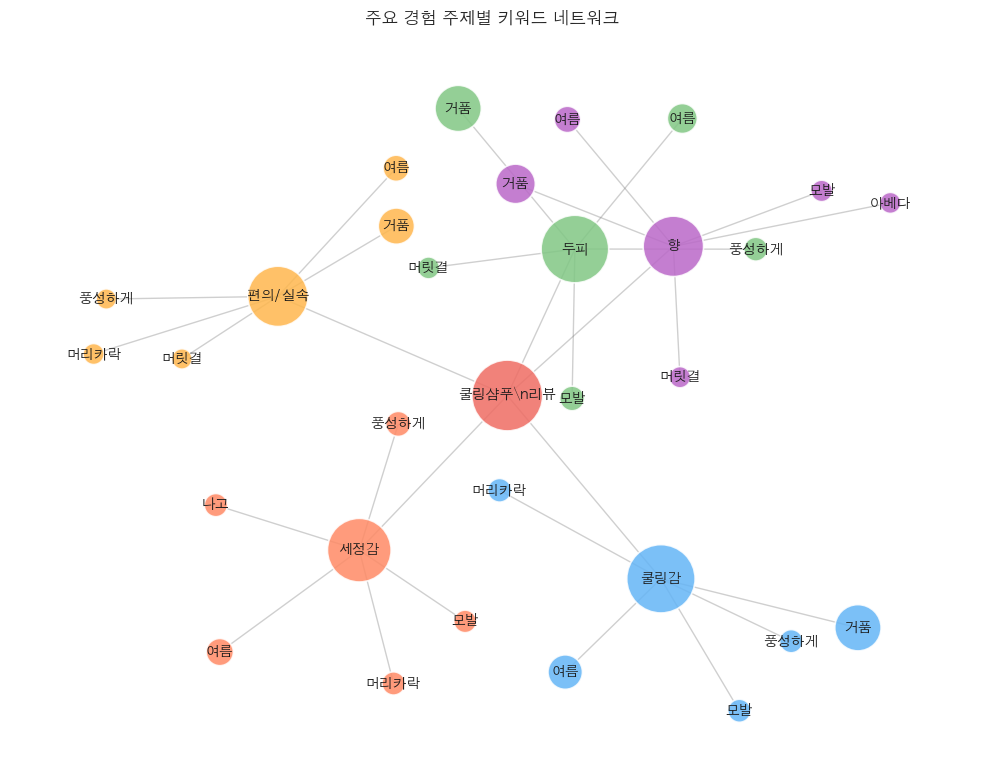

,주제,연결키워드,동시등장빈도
0,쿨링감,거품,204
1,쿨링감,여름,105
2,쿨링감,머리카락,40
3,쿨링감,풍성하게,38
4,쿨링감,모발,37
5,세정감,여름,59
6,세정감,풍성하게,47
7,세정감,나고,38
8,세정감,머리카락,38
9,세정감,모발,35


In [11]:
# 주요 주제별 키워드 네트워크 시각화
theme_patterns = {
    "쿨링감": r"쿨링|시원|청량|개운|상쾌|멘톨|민트|열감",
    "세정감": r"거품|세정|뽀득|산뜻|감고|샴푸바",
    "두피": r"두피|탈모|머리카락|가려움|각질|비듬|유분|지성|기름|떡짐",
    "향": r"향|냄새|향기|잔향|레몬|자몽|허브|라벤더|민트향",
    "편의/실속": r"사용하기|간편|가격|가성비|할인|구성|용량|리필|재구매|드라이샴푸",
}

theme_colors = {
    "쿨링감": "#64B5F6",
    "세정감": "#FF8A65",
    "두피": "#81C784",
    "향": "#BA68C8",
    "편의/실속": "#FFB74D",
}

network_noise_words = keyword_noise_words | set(theme_patterns.keys()) | {
    "시원", "시원한", "세정", "세정력", "향", "냄새", "두피", "사용하기", "드라",
}

theme_keyword_rows = []
for theme, pattern in theme_patterns.items():
    theme_reviews = review_data[review_data["정제리뷰"].str.contains(pattern, regex=True, na=False)]
    theme_tokens = [
        token
        for tokens in theme_reviews["키워드토큰"]
        for token in tokens
        if token not in network_noise_words and not re.search(pattern, token)
    ]
    for keyword, count in Counter(theme_tokens).most_common(5):
        theme_keyword_rows.append({"주제": theme, "연결키워드": keyword, "동시등장빈도": count})

theme_keyword_network = pd.DataFrame(theme_keyword_rows)

G = nx.Graph()
G.add_node("center", label="쿨링샴푸\\n리뷰", size=2600, color="#EF6C63")

for theme, pattern in theme_patterns.items():
    theme_size = review_data["정제리뷰"].str.contains(pattern, regex=True, na=False).sum()
    G.add_node(theme, label=theme, size=900 + theme_size * 4, color=theme_colors[theme])
    G.add_edge("center", theme)

for _, row in theme_keyword_network.iterrows():
    node_id = f"{row['주제']}::{row['연결키워드']}"
    G.add_node(
        node_id,
        label=row["연결키워드"],
        size=90 + row["동시등장빈도"] * 5,
        color=theme_colors[row["주제"]],
    )
    G.add_edge(row["주제"], node_id)

pos = nx.spring_layout(G, seed=42, k=0.95, iterations=100)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.35, edge_color="#777777")
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[G.nodes[node]["size"] for node in G.nodes],
    node_color=[G.nodes[node]["color"] for node in G.nodes],
    alpha=0.85,
    edgecolors="white",
    linewidths=1.2,
)
nx.draw_networkx_labels(
    G,
    pos,
    labels={node: G.nodes[node]["label"] for node in G.nodes},
    font_family="AppleGothic",
    font_size=10,
)
plt.title("주요 경험 주제별 키워드 네트워크", pad=16)
plt.axis("off")
plt.tight_layout()
plt.show()

theme_keyword_network


<b>키워드 네트워크에서 확인한 점</b>

네트워크는 `쿨링샴푸 리뷰`를 중심으로, 소비자가 자주 함께 말한 경험 주제와 세부 키워드를 연결해 보여줍니다. 큰 주제 노드는 언급 리뷰 수가 많을수록 크게 보이고, 주변 키워드는 해당 주제 리뷰 안에서 자주 함께 나온 표현입니다.

`쿨링감`, `세정감`, `두피`는 따로 떨어진 메시지가 아니라 하나의 사용 경험 안에서 같이 움직입니다. 쿨링은 `여름`, `기분`, `개운함`처럼 즉각 체감 언어와 연결되고, 세정감은 `거품`, `풍성함`, `머릿결`처럼 사용 과정의 언어와 연결됩니다.

따라서 상세페이지 메시지는 `시원함`만 단독으로 밀기보다, `시원하게 감기고 풍성한 거품으로 개운하게 마무리되는 두피 케어`처럼 연결된 경험으로 구성하는 편이 더 자연스럽습니다.


### 6-2-3. 그룹별 키워드 비교

전체 키워드에서 한 단계 더 들어가 브랜드, 평점, 도움돼요구간, 가격대별로 자주 등장하는 단어를 비교합니다.  
그룹별 리뷰 수가 다르기 때문에 빈도는 절대 비교보다, 각 그룹에서 두드러지는 표현을 읽는 용도로 봅니다.


In [12]:
# 상위 12개 주요 키워드 빈도 확인
keyword_freq.head(12)


,키워드,빈도
0,거품,273
1,여름,119
2,세정력,111
3,사용하기,90
4,시원한,89
5,머리카락,57
6,모발,53
7,냄새,49
8,풍성하게,47
9,지성,47


In [13]:
def top_keywords_by_group(data, group_col, token_col="키워드토큰", top_n=10, min_reviews=5):
    rows = []
    for group, group_df in data.groupby(group_col, observed=False):
        if pd.isna(group) or len(group_df) < min_reviews:
            continue
        for keyword, count in Counter(sum(group_df[token_col].tolist(), [])).most_common(top_n):
            rows.append({group_col: group, "리뷰수": len(group_df), "키워드": keyword, "빈도": count})
    return pd.DataFrame(rows)

brand_keyword_top = top_keywords_by_group(review_data, "브랜드", top_n=8, min_reviews=20)
rating_keyword_top = top_keywords_by_group(review_data, "리뷰평점", top_n=8, min_reviews=5)
help_keyword_top = top_keywords_by_group(review_data, "도움돼요구간", top_n=8, min_reviews=5)
price_keyword_top = top_keywords_by_group(review_data, "가격대", top_n=8, min_reviews=5)

brand_noise_words = keyword_noise_words | {
    "후기", "판매자", "지원받았지만", "일부", "구매했", "좋았", "일단", "원래",
    "그래", "때문", "분들", "사용할", "사용해", "쓰고",
}

def is_brand_keyword(token, brand):
    token_text = str(token).replace(" ", "")
    brand_text = str(brand).replace(" ", "")
    return token_text in brand_text or brand_text in token_text

def filtered_token_counts(token_lists, brand=None, top_n=40):
    counter = Counter(token for tokens in token_lists for token in tokens)
    return [
        (keyword, count)
        for keyword, count in counter.most_common(top_n)
        if keyword not in brand_noise_words and (brand is None or not is_brand_keyword(keyword, brand))
    ]

def make_brand_keyword_profile(data, min_reviews=20):
    total_counter = Counter(token for tokens in data["키워드토큰"] for token in tokens)
    total_count = sum(total_counter.values())
    rows = []

    for brand, brand_df in data.groupby("브랜드", observed=False):
        if len(brand_df) < min_reviews:
            continue
        tokens = filtered_token_counts(brand_df["키워드토큰"], brand=brand)
        if not tokens:
            continue

        brand_count = sum(Counter(token for token_list in brand_df["키워드토큰"] for token in token_list).values())
        lift_table = pd.DataFrame({
            "키워드": [keyword for keyword, _ in tokens[:20]],
            "브랜드내비중(%)": [count / brand_count * 100 for keyword, count in tokens[:20]],
            "차별도": [count / brand_count - total_counter[keyword] / total_count for keyword, count in tokens[:20]],
        })
        distinctive = lift_table.sort_values(["차별도", "브랜드내비중(%)"], ascending=False)["키워드"].head(3)
        representative = [keyword for keyword, _ in tokens[:3]]

        rows.append({
            "브랜드": brand,
            "리뷰수": len(brand_df),
            "대표 키워드": ", ".join(representative),
            "차별 키워드": ", ".join(distinctive),
            "평균평점": round(brand_df["리뷰평점"].mean(), 2),
            "평균도움돼요점수": round(brand_df["도움돼요점수"].mean(), 2),
        })

    profile = pd.DataFrame(rows).sort_values(["리뷰수", "평균도움돼요점수"], ascending=False).reset_index(drop=True)
    profile["한 줄 해석"] = profile.apply(lambda row: f"대표: {row['대표 키워드']} / 차별: {row['차별 키워드']}", axis=1)
    return profile

brand_keyword_profile = make_brand_keyword_profile(review_data)
brand_keyword_profile.head(8)


,브랜드,리뷰수,대표 키워드,차별 키워드,평균평점,평균도움돼요점수,한 줄 해석
0,달리프,65,"드라이샴푸, 머리카락, 여름","드라이샴푸, 드라, 머리카락",4.66,2.23,"대표: 드라이샴푸, 머리카락, 여름 / 차별: 드라이샴푸, 드라, 머리카락"
1,클로란,55,"거품, 여름, 냄새","거품, 민트향, 냄새",4.71,2.87,"대표: 거품, 여름, 냄새 / 차별: 거품, 민트향, 냄새"
2,온더바디,41,"거품, 복숭아, 욕실","복숭아, 욕실, 발을씻자",4.93,4.00,"대표: 거품, 복숭아, 욕실 / 차별: 복숭아, 욕실, 발을씻자"
3,닥터그루트,40,"거품, 여름, 제품비","제품비, 솔직한, 쿨링샴푸",4.80,1.52,"대표: 거품, 여름, 제품비 / 차별: 제품비, 솔직한, 쿨링샴푸"
4,려,39,"거품, 사용하기, 세정력","모발, 사용하기, 볼륨",4.92,3.64,"대표: 거품, 사용하기, 세정력 / 차별: 모발, 사용하기, 볼륨"
5,라보에이치,39,"거품, 세정력, 사용하기","지성, 트리트먼트, 사용하기",4.82,3.38,"대표: 거품, 세정력, 사용하기 / 차별: 지성, 트리트먼트, 사용하기"
6,아베다,35,"거품, 시원한, 민트","민트, 보통, 로즈마리",4.74,1.66,"대표: 거품, 시원한, 민트 / 차별: 민트, 보통, 로즈마리"
7,닥터포헤어,22,"거품, 여름, 세정력","여름, 거품, 나고",4.86,3.55,"대표: 거품, 여름, 세정력 / 차별: 여름, 거품, 나고"


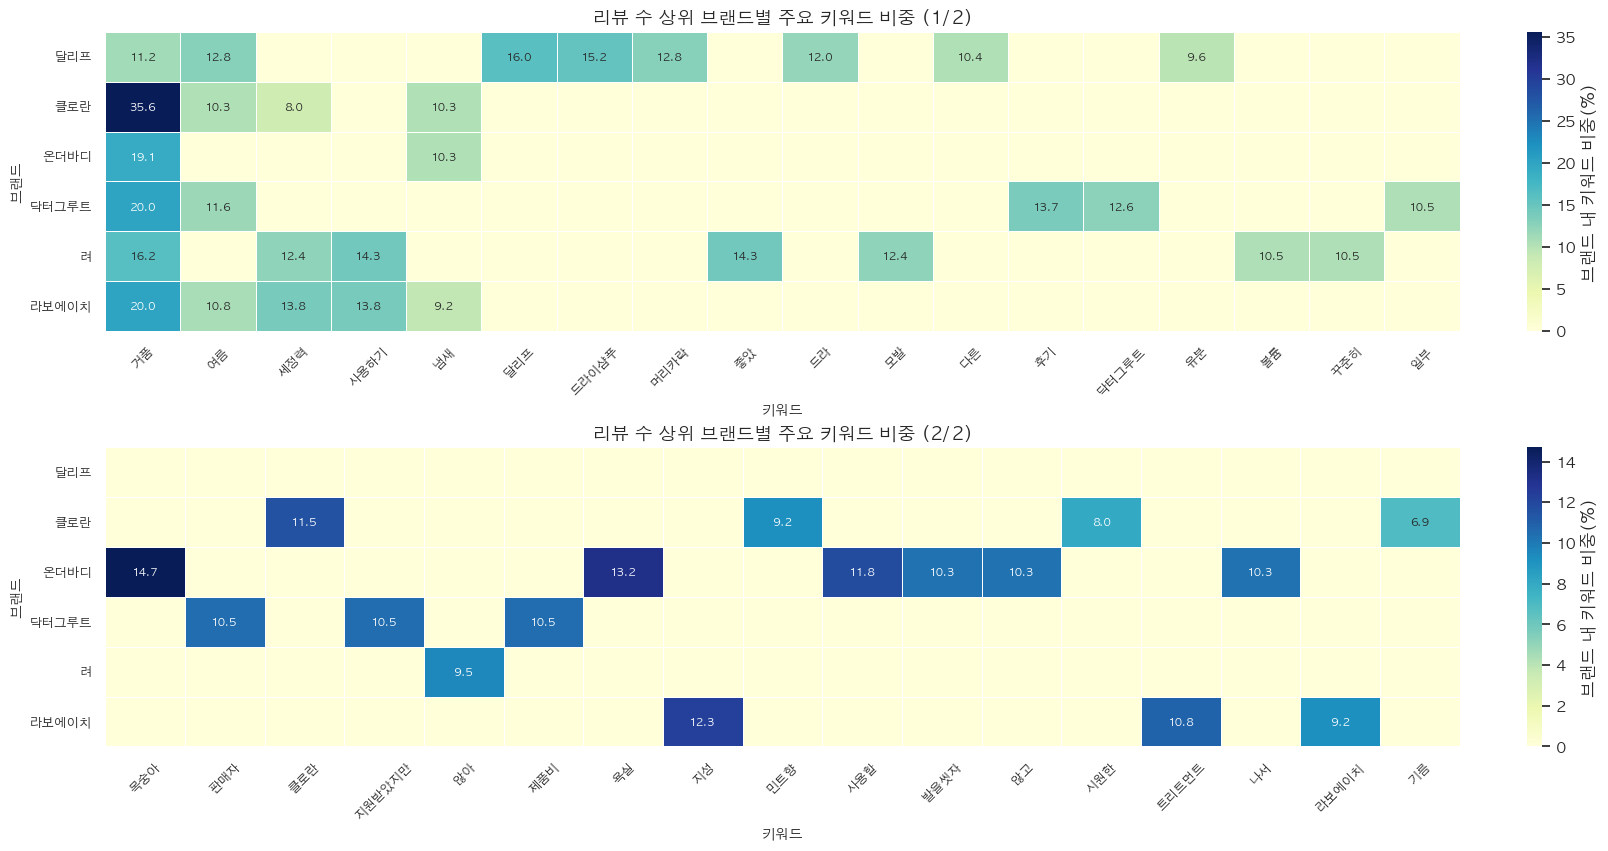

,브랜드,키워드,빈도,키워드비중
24,닥터그루트,거품,19,20.00
25,닥터그루트,후기,13,13.70
26,닥터그루트,닥터그루트,12,12.60
27,닥터그루트,여름,11,11.60
28,닥터그루트,판매자,10,10.50
0,달리프,달리프,20,16.00
1,달리프,드라이샴푸,19,15.20
2,달리프,머리카락,16,12.80
3,달리프,여름,16,12.80
4,달리프,드라,15,12.00


In [14]:
# 브랜드별 키워드는 리뷰 수 상위 브랜드만 히트맵으로 비교합니다.
# 브랜드별로 어떤 사용 경험이 더 강하게 연결되는지 비교합니다.
top_brands = review_data["브랜드"].value_counts().head(6).index
brand_keyword_matrix_rows = []

for brand in top_brands:
    brand_tokens = [token for tokens in review_data.loc[review_data["브랜드"] == brand, "키워드토큰"] for token in tokens]
    counter = Counter(brand_tokens)
    for keyword, count in counter.most_common(8):
        brand_keyword_matrix_rows.append({"브랜드": brand, "키워드": keyword, "빈도": count})

brand_keyword_matrix = pd.DataFrame(brand_keyword_matrix_rows)

top_heatmap_keywords = (
    brand_keyword_matrix
    .groupby("키워드")["빈도"]
    .sum()
    .sort_values(ascending=False)
    .index
)

brand_keyword_pivot = (
    brand_keyword_matrix
    .pivot_table(index="브랜드", columns="키워드", values="빈도", aggfunc="sum", fill_value=0)
    .reindex(index=top_brands, columns=top_heatmap_keywords)
)

# 브랜드별 리뷰 수 차이를 줄이기 위해 행 기준 비율로 확인합니다.
brand_keyword_ratio = brand_keyword_pivot.div(brand_keyword_pivot.sum(axis=1), axis=0).mul(100).round(1)
brand_keyword_annot = brand_keyword_ratio.map(lambda value: "" if value == 0 else f"{value:.1f}")

keyword_chunk_size = 18
keyword_chunks = [
    list(top_heatmap_keywords[i:i + keyword_chunk_size])
    for i in range(0, len(top_heatmap_keywords), keyword_chunk_size)
]

fig, axes = plt.subplots(
    len(keyword_chunks),
    1,
    figsize=(16, 4.2 * len(keyword_chunks)),
    constrained_layout=True,
)

if len(keyword_chunks) == 1:
    axes = [axes]

for idx, keywords in enumerate(keyword_chunks):
    ax = axes[idx]
    sns.heatmap(
        brand_keyword_ratio[keywords],
        annot=brand_keyword_annot[keywords],
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        cbar_kws={"label": "브랜드 내 키워드 비중(%)"},
        annot_kws={"size": 8},
        ax=ax,
    )
    ax.set_title(f"리뷰 수 상위 브랜드별 주요 키워드 비중 ({idx + 1}/{len(keyword_chunks)})", fontsize=13)
    ax.set_xlabel("키워드", fontsize=10)
    ax.set_ylabel("브랜드", fontsize=10)
    ax.tick_params(axis="x", labelrotation=45, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=9)

plt.show()

brand_keyword_summary = (
    brand_keyword_matrix
    .sort_values(["브랜드", "빈도"], ascending=[True, False])
    .groupby("브랜드")
    .head(5)
    .assign(키워드비중=lambda df: df.apply(
        lambda row: brand_keyword_ratio.loc[row["브랜드"], row["키워드"]],
        axis=1,
    ))
)

brand_keyword_summary


<b>브랜드별 키워드에서 확인한 점</b>

브랜드마다 리뷰에서 기억되는 포인트가 다르게 나타납니다.    
`클로란`은 <b>거품/시원함/향</b>, `라보에이치`는 <b>세정력/지성</b>, `달리프`는 <b>드라이샴푸/여름</b>, `려`는 <b>모발/탈모 관리</b> 쪽으로 차이가 보입니다. 즉 소비자는 모든 브랜드를 단순히 같은 `쿨링 샴푸`로 기억하기보다, 브랜드별 사용 장면과 기대 효과를 다르게 말하고 있습니다.

마케팅에서는 브랜드별 광고 문구를 똑같이 `쿨링 샴푸`로 밀기보다, 리뷰에서 이미 형성된 인식을 살려 메시지를 나누는 편이 좋습니다.

- `클로란`: 여름 두피를 위한 시원한 거품감
- `라보에이치`: 지성 두피를 위한 세정력
- `달리프`: 여름철 간편한 드라이샴푸
- `려`: 모발/탈모 고민까지 보는 쿨링 케어

다만 `온더바디`처럼 풋샴푸/생활용품 사용 장면이 강하게 섞인 브랜드는 두피 샴푸 인사이트로 바로 일반화하기보다, 별도 사용 맥락으로 분리해 해석하는 것이 안전합니다.


In [15]:
comparison_tables = {
    "평점별 키워드": rating_keyword_top,
    "도움돼요구간별 키워드": help_keyword_top,
    "가격대별 키워드": price_keyword_top,
}

table_notes = {
    "평점별 키워드": "낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인",
    "도움돼요구간별 키워드": "도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인",
    "가격대별 키워드": "가격 구간마다 기대하는 사용 경험 차이가 있는지 확인",
}

comparison_keyword_summary = pd.concat(
    [
        table.head(5).assign(분석기준=name, 해석포인트=table_notes[name])
        for name, table in comparison_tables.items()
    ],
    ignore_index=True,
)

comparison_cols = ["분석기준", "해석포인트", "리뷰평점", "도움돼요구간", "가격대", "리뷰수", "키워드", "빈도"]
comparison_keyword_summary[[col for col in comparison_cols if col in comparison_keyword_summary.columns]]


,분석기준,해석포인트,리뷰평점,도움돼요구간,가격대,리뷰수,키워드,빈도
0,평점별 키워드,낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인,2.00,NaN,NaN,8,유분기,3
1,평점별 키워드,낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인,2.00,NaN,NaN,8,지성두피,3
2,평점별 키워드,낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인,2.00,NaN,NaN,8,레몬,2
3,평점별 키워드,낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인,2.00,NaN,NaN,8,후회됩니다,2
4,평점별 키워드,낮은 평점에서만 보이는 단어는 불만 포인트 후보로 확인,2.00,NaN,NaN,8,레몬향,2
5,도움돼요구간별 키워드,도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인,NaN,낮음,NaN,168,거품,50
6,도움돼요구간별 키워드,도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인,NaN,낮음,NaN,168,여름,24
7,도움돼요구간별 키워드,도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인,NaN,낮음,NaN,168,아베다,20
8,도움돼요구간별 키워드,도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인,NaN,낮음,NaN,168,세정력,19
9,도움돼요구간별 키워드,도움돼요가 높은 구간의 단어는 구매 전 참고 포인트 후보로 확인,NaN,낮음,NaN,168,다른,17


### 6-2-4. 긍정/부정 신호 분석

평점만으로는 소비자가 무엇을 좋아했고 무엇을 불편해했는지 알기 어렵습니다.  
그래서 리뷰 문장 안에서 발견되는 표현을 <b>긍정 신호</b>와 <b>부정 신호</b>로 나눠 확인합니다.

히트맵의 값은 전체 리뷰 중 해당 표현이 등장한 비율입니다. 비율이 높을수록 소비자가 자주 말한 만족 포인트 또는 불편 포인트로 해석합니다.


In [16]:
# 긍정/부정 표현 사전
# 감성분석 모델이 아니라 사전 기반 신호 감지입니다.
positive_patterns = {
    "재구매/추천": r"추천|재구매|쟁여|필수템|정착",
    "시원/개운": r"시원|쿨링|청량|개운|상쾌|상큼",
    "향 긍정 신호": r"향.{0,6}(좋|괜찮|은은|상큼)|좋.{0,6}향|향기",
    "세정/유분 긍정 신호": r"세정|깨끗|뽀득|유분|기름|노세범|산뜻",
    "두피 긍정 신호": r"두피.{0,8}(좋|편|진정|가려움|각질)|가려움.{0,8}(줄|없)",
    "가격/구성 긍정 신호": r"저렴|가성비|할인|특가|구성.{0,6}좋|용량.{0,6}넉넉",
}

negative_patterns = {
    "자극/따가움": r"자극|따갑|화끈|아프|쓰라|민감|트러블",
    "건조/뻣뻣": r"건조|뻣뻣|푸석|엉킴|가려움",
    "향 부정 신호": r"향.{0,8}(강|별로|싫|인공|독|머리 아)|냄새.{0,8}(강|별로|싫|독)",
    "쿨링 부정 신호": r"안시원|시원.{0,8}않|쿨링.{0,8}(약|없|부족)",
    "세정/효과 부정 신호": r"효과.{0,8}(없|모르)|기름.{0,8}(그대로|빨리)|세정.{0,8}(약|부족)",
    "가격/구성 부정 신호": r"비싸|가격.{0,8}(부담|비쌈|아쉽)|용량.{0,8}(작|적)|구성.{0,8}아쉽",
}

focus_patterns = {
    "쿨링감": r"쿨링|시원|청량|개운|상쾌|멘톨|민트",
    "향": r"향|냄새|향기|레몬|자몽|민트|라벤더|허브",
    "두피": r"두피|가려움|각질|유분|기름|떡짐|탈모|비듬",
    "자극": r"자극|따갑|화끈|민감|트러블|건조|가려움",
    "가격/구성": r"가격|가성비|할인|특가|구성|기획|증정|용량|리필|대용량",
}

def count_pattern_hits(data, pattern_dict, text_col="정제리뷰"):
    rows = []
    for label, pattern in pattern_dict.items():
        mask = data[text_col].str.contains(pattern, regex=True, na=False)
        rows.append({
            "표현그룹": label,
            "리뷰수": int(mask.sum()),
            "비율(%)": round(mask.mean() * 100, 1),
            "평균평점": round(data.loc[mask, "리뷰평점"].mean(), 2) if mask.any() else np.nan,
            "평균도움돼요점수": round(data.loc[mask, "도움돼요점수"].mean(), 1) if mask.any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values("리뷰수", ascending=False)

positive_summary = count_pattern_hits(review_data, positive_patterns)
negative_summary = count_pattern_hits(review_data, negative_patterns)
focus_summary = count_pattern_hits(review_data, focus_patterns)

positive_summary.head(6)


,표현그룹,리뷰수,비율(%),평균평점,평균도움돼요점수
1,시원/개운,372,57.80,4.80,2.50
3,세정/유분 긍정 신호,236,36.60,4.82,2.50
0,재구매/추천,145,22.50,4.82,2.60
2,향 긍정 신호,82,12.70,4.89,2.50
4,두피 긍정 신호,62,9.60,4.84,2.10
5,가격/구성 긍정 신호,55,8.50,4.85,2.20


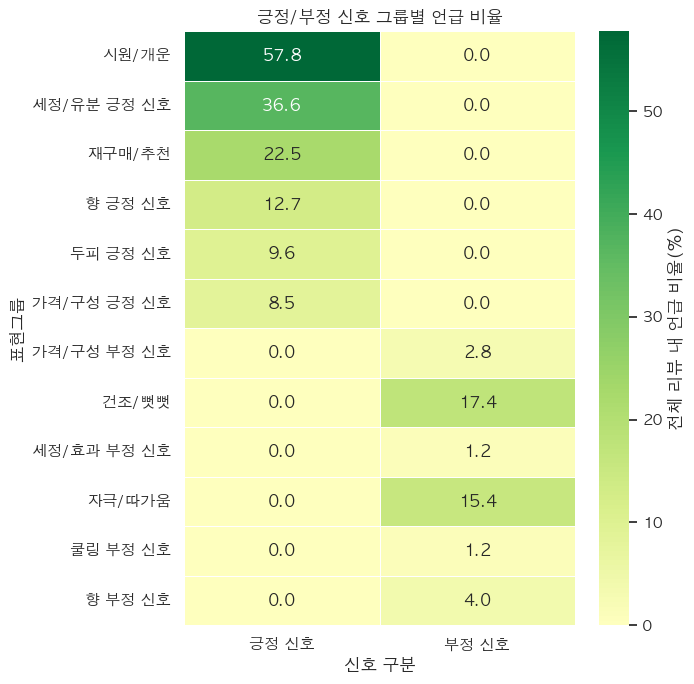

,표현그룹,리뷰수,비율(%),평균평점,평균도움돼요점수,구분
0,시원/개운,372,57.80,4.80,2.50,긍정 신호
1,세정/유분 긍정 신호,236,36.60,4.82,2.50,긍정 신호
2,재구매/추천,145,22.50,4.82,2.60,긍정 신호
3,향 긍정 신호,82,12.70,4.89,2.50,긍정 신호
4,두피 긍정 신호,62,9.60,4.84,2.10,긍정 신호
5,가격/구성 긍정 신호,55,8.50,4.85,2.20,긍정 신호
6,건조/뻣뻣,112,17.40,4.78,2.60,부정 신호
7,자극/따가움,99,15.40,4.77,2.50,부정 신호
8,향 부정 신호,26,4.00,4.50,2.60,부정 신호
9,가격/구성 부정 신호,18,2.80,4.78,1.70,부정 신호


In [17]:
# 긍정/부정 신호 요약 비교
sentiment_keyword_summary = pd.concat([
    positive_summary.assign(구분="긍정 신호"),
    negative_summary.assign(구분="부정 신호"),
], ignore_index=True)

sentiment_pivot = (
    sentiment_keyword_summary
    .pivot_table(index="표현그룹", columns="구분", values="비율(%)", fill_value=0)
    .sort_values(sentiment_keyword_summary["구분"].iloc[0] if False else "긍정 신호", ascending=False)
)

plt.figure(figsize=(7, 7))
sns.heatmap(
    sentiment_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "전체 리뷰 내 언급 비율(%)"},
)
plt.title("긍정/부정 신호 그룹별 언급 비율")
plt.xlabel("신호 구분")
plt.ylabel("표현그룹")
plt.tight_layout()
plt.show()

sentiment_keyword_summary


<b>긍정/부정 신호에서 확인한 점</b>

긍정 신호에서는 `시원/개운`이 <b>57.8%</b>로 가장 크고, `세정/유분 긍정 신호`가 <b>36.6%</b>로 뒤를 이었습니다. `재구매/추천`도 <b>22.5%</b>로 나타나, 시원함과 세정감이 만족과 추천 의향으로 이어질 가능성이 보입니다.

부정 신호에서는 `건조/뻣뻣`이 <b>17.4%</b>, `자극/따가움`이 <b>15.4%</b>로 크게 잡혔습니다. 쿨링 샴푸의 불편 포인트는 단순히 “덜 시원함”이 아니라, 감은 뒤 머릿결이 뻣뻣해지거나 두피가 자극적으로 느껴지는 경험에 가깝습니다.

- <b>핵심 기회</b>: 개운함 + 세정감
- <b>관리해야 할 리스크</b>: 자극감 + 감은 뒤 건조함

따라서 제품 메시지는 “시원하다”에서 끝나면 안 됩니다. `시원하고 개운한 쿨링감`을 메인으로 두되, `두피는 편안하게`, `머릿결은 뻣뻣하지 않게` 같은 안심 메시지를 함께 가져가는 편이 좋습니다.


#### 핵심 경험 주제 확인

긍정/부정 신호를 본 뒤에는 리뷰가 어떤 경험 주제를 중심으로 쓰였는지 확인합니다.  
버블 차트에서는 오른쪽에 있을수록 자주 언급된 주제이고, 위쪽에 있을수록 평균 평점이 높은 주제입니다. 버블이 클수록 도움돼요 반응이 높은 리뷰에서 자주 등장한 주제로 봅니다.


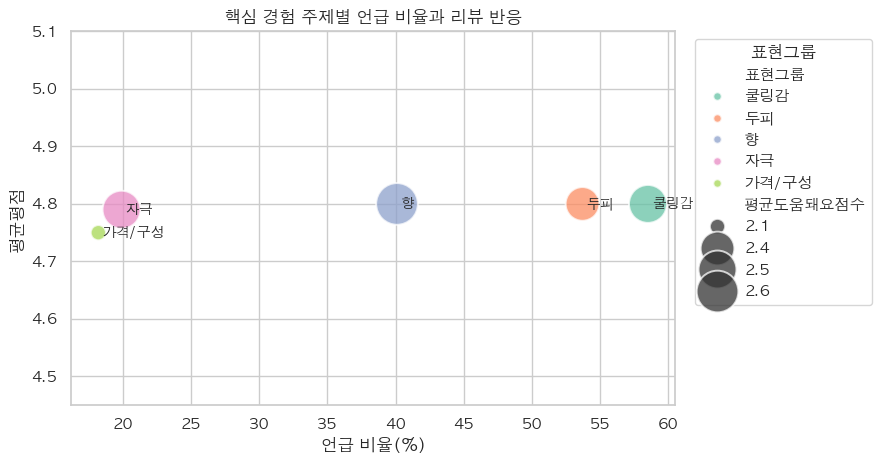

,표현그룹,리뷰수,비율(%),평균평점,평균도움돼요점수
0,쿨링감,377,58.50,4.80,2.50
2,두피,346,53.70,4.80,2.40
1,향,258,40.10,4.80,2.60
3,자극,128,19.90,4.79,2.50
4,가격/구성,117,18.20,4.75,2.10


In [18]:
# 핵심 경험 주제별 언급 비율과 반응 비교
focus_plot = focus_summary.copy()
focus_plot["버블크기"] = focus_plot["평균도움돼요점수"].fillna(0).clip(lower=1) * 8

plt.figure(figsize=(9, 4.8))
sns.scatterplot(
    data=focus_plot,
    x="비율(%)",
    y="평균평점",
    size="평균도움돼요점수",
    hue="표현그룹",
    sizes=(120, 900),
    alpha=0.75,
    palette="Set2",
)

for _, row in focus_plot.iterrows():
    plt.text(row["비율(%)"] + 0.3, row["평균평점"], row["표현그룹"], va="center", fontsize=10)

plt.title("핵심 경험 주제별 언급 비율과 리뷰 반응")
plt.xlabel("언급 비율(%)")
plt.ylabel("평균평점")
plt.ylim(max(0, focus_plot["평균평점"].min() - 0.3), 5.1)
plt.legend(title="표현그룹", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

focus_summary


<b>핵심 경험 주제에서 확인한 점</b>

핵심 주제 중 `쿨링감`은 <b>58.5%</b>, `두피`는 <b>53.7%</b>, `향`은 <b>40.1%</b>로 많이 언급됩니다.  
평점은 전반적으로 높지만, `가격/구성`은 언급 비율이 <b>18.2%</b>로 낮고 평균평점도 상대적으로 낮은 편입니다.

마케팅 우선순위는 `쿨링감 -> 두피/세정 -> 향` 순서가 자연스럽습니다. 가격/구성은 주 메시지라기보다 구매 전환을 돕는 보조 장치로 쓰는 편이 좋아 보입니다.


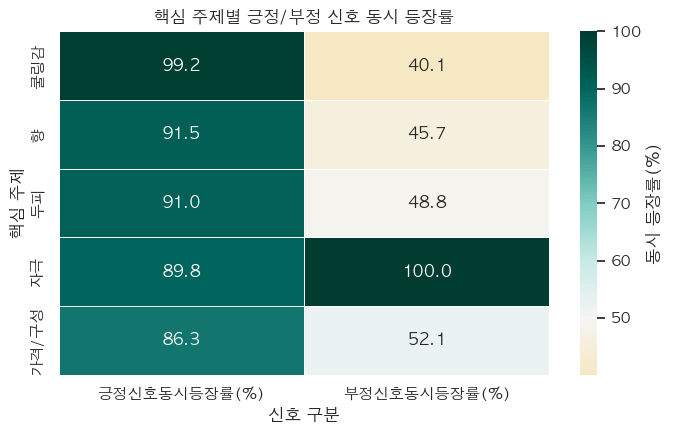

,핵심주제,언급리뷰수,긍정신호동시등장률(%),부정신호동시등장률(%),평균평점
0,쿨링감,377,99.20,40.10,4.80
1,향,258,91.50,45.70,4.80
2,두피,346,91.00,48.80,4.80
3,자극,128,89.80,100.00,4.79
4,가격/구성,117,86.30,52.10,4.75


In [19]:
# 핵심 주제와 긍정/부정 신호의 동시 등장 확인
cooccurrence_rows = []
positive_union_pattern = "|".join(positive_patterns.values())
negative_union_pattern = "|".join(negative_patterns.values())

for focus_label, focus_pattern in focus_patterns.items():
    focus_mask = review_data["정제리뷰"].str.contains(focus_pattern, regex=True, na=False)
    focus_df = review_data[focus_mask]
    if len(focus_df) == 0:
        continue

    positive_mask = focus_df["정제리뷰"].str.contains(positive_union_pattern, regex=True, na=False)
    negative_mask = focus_df["정제리뷰"].str.contains(negative_union_pattern, regex=True, na=False)

    cooccurrence_rows.append({
        "핵심주제": focus_label,
        "언급리뷰수": len(focus_df),
        "긍정신호동시등장률(%)": round(positive_mask.mean() * 100, 1),
        "부정신호동시등장률(%)": round(negative_mask.mean() * 100, 1),
        "평균평점": round(focus_df["리뷰평점"].mean(), 2),
    })

focus_sentiment_compare = pd.DataFrame(cooccurrence_rows)
focus_sentiment_heatmap = focus_sentiment_compare.set_index("핵심주제")[["긍정신호동시등장률(%)", "부정신호동시등장률(%)"]]

plt.figure(figsize=(7, 4.5))
sns.heatmap(
    focus_sentiment_heatmap,
    annot=True,
    fmt=".1f",
    cmap="BrBG",
    center=50,
    linewidths=0.5,
    cbar_kws={"label": "동시 등장률(%)"},
)
plt.title("핵심 주제별 긍정/부정 신호 동시 등장률")
plt.xlabel("신호 구분")
plt.ylabel("핵심 주제")
plt.tight_layout()
plt.show()

focus_sentiment_compare


<b>핵심 주제와 긍정/부정 신호 동시 등장에서 확인한 점</b>

히트맵은 특정 주제가 언급된 리뷰 안에서 긍정 신호와 부정 신호가 함께 나온 비율을 보여줍니다. 같은 `쿨링감` 리뷰라도 만족 표현과 불안 표현이 동시에 나올 수 있기 때문에, 단순 빈도보다 메시지 리스크를 읽는 데 좋습니다.

`쿨링감`은 긍정 신호 동시 등장률이 <b>99.2%</b>로 가장 높아, 제품의 핵심 후킹 포인트로 쓰기 좋습니다. 다만 부정 신호도 <b>40.1%</b> 함께 나타나므로 `강하지만 편안한 쿨링`, `사용 후 건조하지 않은 마무리` 같은 방어 문구가 필요합니다.

`자극`은 부정 신호 동시 등장률이 <b>100.0%</b>입니다. 이 주제는 장점보다 구매 장벽에 가까우므로, 상세페이지에서는 저자극 테스트, 민감 두피 사용 가능성, 사용 후 두피 편안함을 근거로 보강하는 편이 좋습니다.

`두피`, `향`, `가격/구성`은 긍정 신호도 높지만 부정 신호가 함께 나타납니다. 그래서 이 세 주제는 메인 후킹보다는 구매 직전의 불안을 줄이는 보조 메시지로 쓰는 것이 자연스럽습니다.


#### 쿨링 니즈와 구매 장벽 확인

쿨링이 얼마나 자주 언급되는지와 함께, 강한 쿨링·지속성·자극 회피 같은 장벽 신호를 분리해 봅니다.  
산점도에서는 오른쪽에 있을수록 언급 비율이 높고, 버블이 클수록 해당 표현이 나온 리뷰 수가 많습니다.


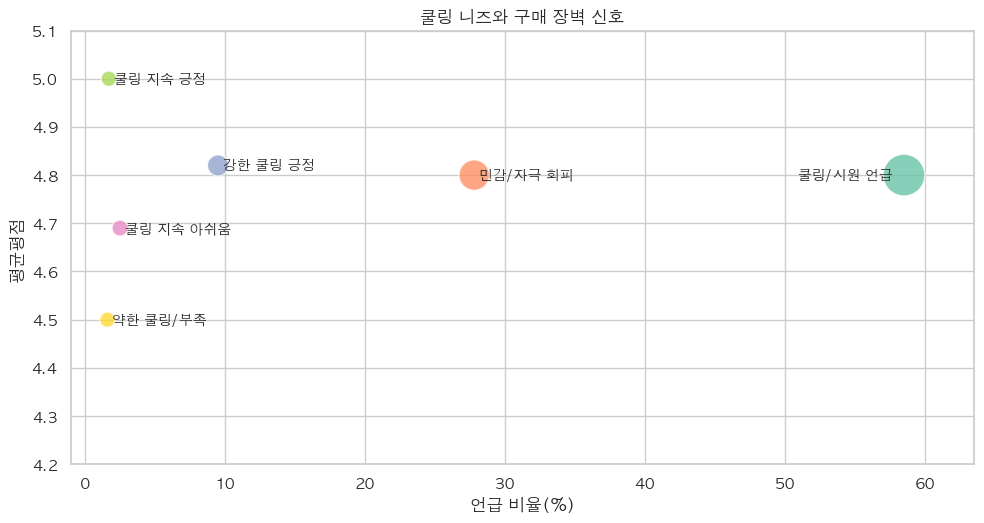

,표현그룹,리뷰수,비율(%),평균평점,평균도움돼요점수
0,쿨링/시원 언급,377,58.50,4.80,2.50
5,민감/자극 회피,179,27.80,4.80,2.50
1,강한 쿨링 긍정,61,9.50,4.82,2.40
3,쿨링 지속 아쉬움,16,2.50,4.69,2.70
2,쿨링 지속 긍정,11,1.70,5.00,2.60
4,약한 쿨링/부족,10,1.60,4.50,2.50


In [20]:
cooling_barrier_patterns = {
    "쿨링/시원 언급": r"쿨링|시원|청량|개운|상쾌|멘톨|민트",
    "강한 쿨링 긍정": r"엄청.{0,6}시원|완전.{0,6}시원|확.{0,6}시원|강력.{0,6}쿨링|쿨링감.{0,6}좋|시원.{0,6}좋",
    "쿨링 지속 긍정": r"오래.{0,8}(시원|개운|상쾌|지속)|지속.{0,8}(시원|쿨링|개운)|하루종일|오랫동안.{0,8}(시원|개운)",
    "쿨링 지속 아쉬움": r"금방.{0,8}(사라|없|끝|날아)|오래.{0,8}안|지속.{0,8}(안|않|짧|약|부족)|쿨링.{0,8}(금방|짧|약|부족|없)|시원.{0,8}(잠깐|금방|오래 안|약)",
    "약한 쿨링/부족": r"안시원|시원.{0,8}않|시원.{0,8}안|쿨링.{0,8}(약|없|부족)|생각보다.{0,8}(약|안시원|덜)",
    "민감/자극 회피": r"민감|자극|따갑|화끈|쓰라|트러블|두피.{0,8}예민|예민.{0,8}두피|건조|뻣뻣|푸석|가려움",
}

cooling_barrier_summary = count_pattern_hits(review_data, cooling_barrier_patterns)

fig, ax = plt.subplots(figsize=(10, 5.4))
sns.scatterplot(
    data=cooling_barrier_summary,
    x="비율(%)",
    y="평균평점",
    size="리뷰수",
    hue="표현그룹",
    sizes=(120, 900),
    alpha=0.78,
    palette="Set2",
    ax=ax,
    legend=False,
)

x_max = cooling_barrier_summary["비율(%)"].max()
for _, row in cooling_barrier_summary.iterrows():
    is_right_edge = row["비율(%)"] > x_max * 0.75
    x_offset = -0.8 if is_right_edge else 0.35
    ha = "right" if is_right_edge else "left"
    ax.text(row["비율(%)"] + x_offset, row["평균평점"], row["표현그룹"], va="center", ha=ha, fontsize=10)

ax.set_title("쿨링 니즈와 구매 장벽 신호")
ax.set_xlabel("언급 비율(%)")
ax.set_ylabel("평균평점")
ax.set_xlim(-1, x_max + 5)
ax.set_ylim(max(0, cooling_barrier_summary["평균평점"].min() - 0.3), 5.1)
plt.tight_layout()
plt.show()

cooling_barrier_summary


<b>쿨링 니즈와 구매 장벽에서 확인한 점</b>

쿨링/시원 언급은 <b>58.5%</b>로 높지만, `강한 쿨링 긍정`은 <b>9.5%</b>에 그쳤습니다. 리뷰에서 쿨링은 중요한 주제지만, 소비자가 항상 “더 강한 쿨링”만 원하는 것은 아닙니다.

오히려 `민감/자극 회피` 신호가 <b>27.8%</b>로 꽤 크게 나타났습니다. 이는 쿨링 제품을 꺼리는 이유가 니즈 부족이 아니라 <b>자극, 건조함, 예민한 두피에 대한 불안</b>일 수 있다는 점을 보여줍니다.

신제품 방향은 `강한 쿨링` 하나보다 <b>민감 두피도 부담 없이 쓰는 지속 쿨링 샴푸</b>가 더 설득력 있어 보입니다. 광고도 “얼얼하게 시원함”보다 `오래 가는 개운함`, `두피 부담 낮은 쿨링`, `매일 써도 편안한 쿨링감` 쪽이 더 안전합니다.


<b>긍정/부정 신호를 함께 봤을 때 확인한 점</b>

쿨링감, 두피, 향 같은 핵심 주제는 긍정 신호와 자주 함께 등장하지만, 부정 신호와 완전히 분리되지는 않습니다. 특히 `두피`, `자극` 관련 표현은 긍정 리뷰 안에서도 민감한 사용감 이슈와 같이 나타날 수 있습니다.

따라서 메시지는 과장된 “강력 쿨링”보다 `개운하지만 부담 없는`, `두피가 편안한`, `매일 쓰기 좋은` 쪽이 더 안전합니다.


In [21]:
positive_review_samples = review_data[
    review_data["정제리뷰"].str.contains(positive_union_pattern, regex=True, na=False)
].sort_values(["리뷰평점", "도움돼요점수"], ascending=[False, False]).head(5)

negative_review_samples = review_data[
    review_data["정제리뷰"].str.contains(negative_union_pattern, regex=True, na=False)
].sort_values(["리뷰평점", "도움돼요점수"], ascending=[True, False]).head(5)

sample_cols = ["신호구분", "브랜드", "가격대", "리뷰평점", "도움돼요구간", "리뷰요약"]
review_signal_samples = pd.concat([
    positive_review_samples.assign(신호구분="긍정 신호"),
    negative_review_samples.assign(신호구분="부정 신호"),
])

review_signal_samples.assign(
    리뷰요약=review_signal_samples["리뷰내용"].str.slice(0, 90) + "..."
)[sample_cols]


,신호구분,브랜드,가격대,리뷰평점,도움돼요구간,리뷰요약
0,긍정 신호,온더바디,1만원 미만,5,매우 높음,곰팡이까지 없애주는 발을 씻자!! 떨어지면 무조건 쟁여야 합니다...
1,긍정 신호,온더바디,1만원 미만,5,매우 높음,"여름 대비 필수템입니다. 발 전용 세정제라 처음에는 굳이 필요할까 싶었는데, 사용해보니 일반 바디워시와는 확실히 차이가 있었습니다. 스프레이 타입이라 손에 묻히지..."
2,긍정 신호,온더바디,1만원 미만,5,매우 높음,🏷️사용감 분사하자마자 상큼달달한 자몽껌 향이 화장실에 확 퍼집니다 인위적이지 않아서 씻을 때마다 기분이 너무 좋아요 민트 성분 덕분에 다 씻고 나면 발이 엄청 ...
3,긍정 신호,온더바디,1만원 미만,5,매우 높음,비누체로 하기에는 귀찮아서 스프레이로 보드리면 간편해서 샀어요. 시원해요....
6,긍정 신호,온더바디,1만원 미만,5,매우 높음,비누향 너무 좋아요 진짜 세탁 비누 그잡채... 요거 하나 있으면 만능이라 슬리퍼 세탁도 하고 욕실 청소도 하고 발도 씻구 ㅎㅎ 여름 필수템이죠!!! 나갔다오면 ...
14,부정 신호,온더바디,1만원 미만,2,매우 높음,하필 대용량인데 레몬을 2통이나 구매해서ㅠ 너무 후회됩니다. 그냥 쓰던 복숭아향을 살껄...향이 바뀐건지 상큼한 레몬향이 아니고 너무 찐한 머스크향에 인공적인 레...
383,부정 신호,동구밭,1만원 미만,2,보통,중건성-지성-쿨링용 순으로 3개월 써봤습니다. 중건성용은 조금 유분기 남아있는 느낌이라 지성에겐 안맞았고 지성용은 왠지 모르게 자꾸 각질제거가 안돼서 두피가 가렵...
556,부정 신호,아닐로,2만원대,2,낮음,"기름기가 잘 씻겨 나가긴 하나 머리를 다 감고 나면 머리가 푸석푸석해지고, 향은 리뷰대로 아빠 스킨향 납니다. 근데 여기서 제일 중요한게 ; 쿨링 효과가 있다고 ..."
237,부정 신호,달리프,1만원대,3,매우 높음,동ㅇ님 추천으로 사봤는데 별로에요. 극지성인들은 효과없네요....
101,부정 신호,라보에이치,1만원대,3,높음,"요즘 날풀리고 머리가 개기름이 많이 올라오는거 같아서 샀습니다.기존에 라보에이치 샴푸를 만족하며 사용했는데,이 제품은 좀 아쉬워요 머리가 너무 뻣뻣해지고 두피기름..."


### 6-2-5. 리뷰 클러스터링

리뷰를 TF-IDF 벡터로 바꾸고, 비슷한 단어 구성을 가진 리뷰끼리 묶습니다.  
군집 수는 마케팅 타겟팅과 페르소나 설정에 활용하기 쉽도록 <b>4개</b>로 고정합니다.

군집은 정답 라벨이 아니라 리뷰를 마케팅 관점에서 해석하기 위한 분석용 세그먼트입니다. 대표 키워드, 주요 관심사, 평점, 가격대, 도움돼요구간을 함께 보고 해석합니다.


In [22]:
def identity_tokenizer(text):
    return text

vectorizer = TfidfVectorizer(
    tokenizer=identity_tokenizer,
    preprocessor=identity_tokenizer,
    token_pattern=None,
    lowercase=False,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 1),
)

X = vectorizer.fit_transform(review_data["키워드토큰"])
feature_names = np.array(vectorizer.get_feature_names_out())

pd.DataFrame({
    "항목": ["리뷰 수", "TF-IDF 키워드 수"],
    "값": X.shape,
})


,항목,값
0,리뷰 수,644
1,TF-IDF 키워드 수,1053


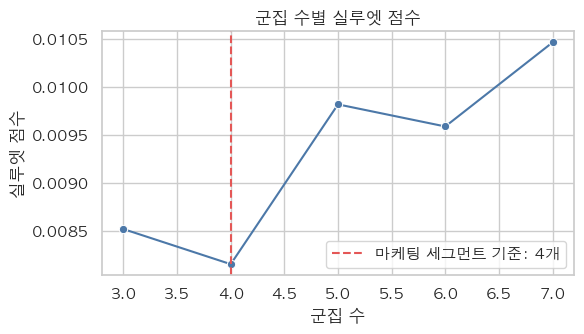

,군집수,실루엣점수
0,3,0.01
1,4,0.01
2,5,0.01
3,6,0.01
4,7,0.01


In [23]:
# 군집 수별 실루엣 점수 확인
# 마케팅 세그먼트 활용을 위해 최종 군집 수는 4개로 고정합니다.
cluster_scores = []
max_k = min(7, len(review_data) - 1)

for k in range(3, max_k + 1):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels) if len(set(labels)) > 1 else np.nan
    cluster_scores.append({"군집수": k, "실루엣점수": score})

cluster_score_df = pd.DataFrame(cluster_scores)

plt.figure(figsize=(6, 3.5))
sns.lineplot(data=cluster_score_df, x="군집수", y="실루엣점수", marker="o", color="#4C78A8")
plt.axvline(4, color="#E45756", linestyle="--", label="마케팅 세그먼트 기준: 4개")
plt.title("군집 수별 실루엣 점수")
plt.xlabel("군집 수")
plt.ylabel("실루엣 점수")
plt.legend()
plt.tight_layout()
plt.show()

cluster_score_df.head(5)


<b>군집 수 설정에서 확인한 점</b>

실루엣 점수는 군집 품질을 참고하기 위한 지표지만, 이번 목적은 모델 성능 최적화가 아니라 <b>마케팅 세그먼트 설계</b>입니다.  
따라서 해석하기 쉬운 4개 군집으로 고정했습니다.

이후 군집은 알고리즘의 정답이라기보다, 광고 타겟·상세페이지 문구·페르소나를 나누기 위한 실무형 분류로 읽으면 됩니다.


In [24]:
fixed_k = 4
kmeans = KMeans(n_clusters=fixed_k, random_state=42, n_init=20)
review_data["리뷰군집"] = kmeans.fit_predict(X)

cluster_count_summary = (
    review_data["리뷰군집"]
    .value_counts()
    .sort_index()
    .rename_axis("리뷰군집")
    .reset_index(name="리뷰수")
)
cluster_count_summary["고정 군집 수"] = fixed_k
cluster_count_summary


,리뷰군집,리뷰수,고정 군집 수
0,0,70,4
1,1,346,4
2,2,125,4
3,3,103,4


In [25]:
order_centroids = kmeans.cluster_centers_.argsort(axis=1)[:, ::-1]

persona_profiles = {
    "쿨링/열감 즉시형": {
        "keywords": {"여름", "열감", "쿨링", "쿨링감", "쿨링제품", "시원", "시원한", "시원해서", "청량", "개운", "상쾌", "멘톨", "민트"},
        "페르소나": "청량감 즉시 체감형",
        "주요관심사": "쿨링/열감",
        "타겟팅 힌트": "여름, 운동 후, 지성/열감 두피처럼 즉각적인 개운함을 원하는 상황을 공략",
        "메시지 방향": "시원함·개운함·상쾌함을 사용 직후 체감 언어로 제시",
    },
    "세정/거품 사용감형": {
        "keywords": {"거품", "세정", "세정력", "풍성", "풍성하게", "뽀득", "산뜻", "머릿결", "샴푸바", "사용감", "감고", "감으면"},
        "페르소나": "세정감 꼼꼼 확인형",
        "주요관심사": "세정/거품",
        "타겟팅 힌트": "거품, 세정력, 머릿결 변화를 꼼꼼히 확인하는 사용감 중심 소비자 공략",
        "메시지 방향": "풍성한 거품·세정력·감은 뒤 머릿결을 실제 사용 장면으로 보여주기",
    },
    "두피/유분 고민형": {
        "keywords": {"두피", "탈모", "머리카락", "가려움", "각질", "비듬", "유분", "기름", "지성", "떡짐", "노세범", "진정"},
        "페르소나": "두피 컨디션 관리형",
        "주요관심사": "두피/유분",
        "타겟팅 힌트": "유분, 가려움, 각질, 떡짐처럼 두피 고민이 분명한 소비자 공략",
        "메시지 방향": "두피 편안함·유분 케어·세정감을 기능적 근거와 함께 제시",
    },
    "향/감각 민감형": {
        "keywords": {"향", "냄새", "향기", "잔향", "레몬", "자몽", "허브", "라벤더", "상큼", "은은"},
        "페르소나": "향 사용감 민감형",
        "주요관심사": "향/감각",
        "타겟팅 힌트": "향 취향, 잔향, 욕실 사용 경험을 중요하게 보는 소비자에게 적합",
        "메시지 방향": "향의 강도와 분위기를 구체적으로 안내하고 호불호를 줄이는 표현 사용",
    },
    "실속/편의 탐색형": {
        "keywords": {"가격", "가성비", "할인", "특가", "구성", "기획", "증정", "용량", "대용량", "리필", "사용하기", "간편", "스프레이", "드라이샴푸", "재구매"},
        "페르소나": "실속 편의 탐색형",
        "주요관심사": "가격/구성/편의",
        "타겟팅 힌트": "대용량, 리필, 기획세트, 간편 사용성을 비교하는 실속형 소비자 공략",
        "메시지 방향": "용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치",
    },
}

def score_persona(cluster_id, top_terms, profile):
    keyword_score = sum(20 - i for i, term in enumerate(top_terms) if term in profile["keywords"])
    pattern = "|".join(profile["keywords"])
    text_score = review_data.loc[review_data["리뷰군집"] == cluster_id, "정제리뷰"].str.contains(pattern, regex=True, na=False).mean() * 10
    return keyword_score + text_score

def assign_cluster_profiles():
    candidates = []
    for cluster_id in range(fixed_k):
        top_terms = list(feature_names[order_centroids[cluster_id, :20]])
        scores = {name: score_persona(cluster_id, top_terms, profile) for name, profile in persona_profiles.items()}
        candidates.append({"리뷰군집": cluster_id, "대표키워드목록": top_terms, "후보점수": scores})

    assigned, used = {}, set()
    for item in sorted(candidates, key=lambda x: max(x["후보점수"].values()), reverse=True):
        ranked = sorted(item["후보점수"], key=item["후보점수"].get, reverse=True)
        selected = next((profile for profile in ranked if profile not in used), ranked[0])
        assigned[item["리뷰군집"]] = selected
        used.add(selected)
    return candidates, assigned

def summarize_cluster(item, selected_profile):
    cluster_id = item["리뷰군집"]
    cluster_df = review_data[review_data["리뷰군집"] == cluster_id]
    persona = persona_profiles[selected_profile]
    return {
        "리뷰군집": cluster_id,
        "페르소나": persona["페르소나"],
        "주요관심사": persona["주요관심사"],
        "리뷰수": len(cluster_df),
        "대표키워드": ", ".join(item["대표키워드목록"][:12]),
        "평균평점": round(cluster_df["리뷰평점"].mean(), 2),
        "평균도움돼요점수": round(cluster_df["도움돼요점수"].mean(), 1),
        "주요가격대": cluster_df["가격대"].value_counts().idxmax(),
        "주요도움돼요구간": cluster_df["도움돼요구간"].value_counts().idxmax(),
        "타겟팅 힌트": persona["타겟팅 힌트"],
        "메시지 방향": persona["메시지 방향"],
    }

cluster_candidates, assigned_profiles = assign_cluster_profiles()
cluster_keyword_summary = pd.DataFrame([
    summarize_cluster(item, assigned_profiles[item["리뷰군집"]])
    for item in cluster_candidates
]).sort_values("리뷰수", ascending=False)

cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사", "리뷰수", "평균평점", "평균도움돼요점수", "주요가격대", "주요도움돼요구간", "메시지 방향"]]


,리뷰군집,페르소나,주요관심사,리뷰수,평균평점,평균도움돼요점수,주요가격대,주요도움돼요구간,메시지 방향
1,1,실속 편의 탐색형,가격/구성/편의,346,4.78,2.40,1만원대,낮음,"용량 대비 가격, 구성 혜택, 사용 편의, 재구매 부담 감소를 전면에 배치"
2,2,세정감 꼼꼼 확인형,세정/거품,125,4.73,2.60,1만원대,보통,풍성한 거품·세정력·감은 뒤 머릿결을 실제 사용 장면으로 보여주기
3,3,두피 컨디션 관리형,두피/유분,103,4.83,2.30,1만원대,보통,두피 편안함·유분 케어·세정감을 기능적 근거와 함께 제시
0,0,청량감 즉시 체감형,쿨링/열감,70,4.79,2.80,1만원대,높음,시원함·개운함·상쾌함을 사용 직후 체감 언어로 제시


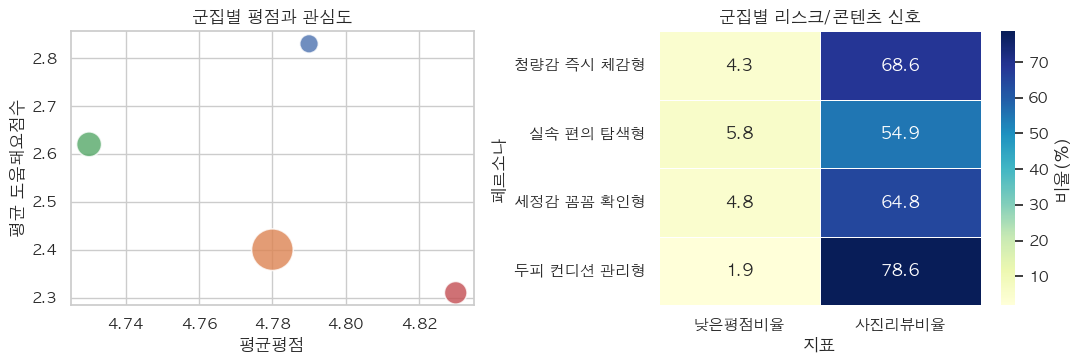

,리뷰군집,페르소나,리뷰수,평균평점,낮은평점비율,평균도움돼요점수,사진리뷰비율
0,0,청량감 즉시 체감형,70,4.79,4.30,2.83,68.60
1,1,실속 편의 탐색형,346,4.78,5.80,2.40,54.90
2,2,세정감 꼼꼼 확인형,125,4.73,4.80,2.62,64.80
3,3,두피 컨디션 관리형,103,4.83,1.90,2.31,78.60


In [26]:
# 군집별 평점/가격대/도움돼요구간 비교
cluster_response_summary = (
    review_data
    .groupby("리뷰군집")
    .agg(
        리뷰수=("리뷰내용", "count"),
        평균평점=("리뷰평점", "mean"),
        낮은평점비율=("리뷰평점", lambda x: round((x <= 3).mean() * 100, 1)),
        평균도움돼요점수=("도움돼요점수", "mean"),
        평균리뷰글자수=("리뷰글자수", "mean"),
        사진리뷰비율=("사진여부", lambda x: round(x.mean() * 100, 1)),
    )
    .round(2)
    .reset_index()
    .merge(cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사"]], on="리뷰군집", how="left")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.scatterplot(
    data=cluster_response_summary,
    x="평균평점",
    y="평균도움돼요점수",
    size="리뷰수",
    hue="페르소나",
    sizes=(180, 900),
    alpha=0.8,
    ax=axes[0],
)
axes[0].set_title("군집별 평점과 관심도")
axes[0].set_xlabel("평균평점")
axes[0].set_ylabel("평균 도움돼요점수")
axes[0].legend_.remove()

sns.heatmap(
    cluster_response_summary.set_index("페르소나")[["낮은평점비율", "사진리뷰비율"]],
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={"label": "비율(%)"},
    ax=axes[1],
)
axes[1].set_title("군집별 리스크/콘텐츠 신호")
axes[1].set_xlabel("지표")
axes[1].set_ylabel("페르소나")
plt.tight_layout()
plt.show()

cluster_response_summary[["리뷰군집", "페르소나", "리뷰수", "평균평점", "낮은평점비율", "평균도움돼요점수", "사진리뷰비율"]]


<b>4개 리뷰 군집에서 확인한 점</b>

4개 군집은 `실속 편의 탐색형`, `세정감 꼼꼼 확인형`, `두피 컨디션 관리형`, `청량감 즉시 체감형`으로 나뉩니다.

- 가장 큰 군집: <b>실속 편의 탐색형(346건)</b>
- 도움돼요 반응이 높은 군집: <b>청량감 즉시 체감형</b>
- 신뢰형 콘텐츠에 적합한 군집: <b>두피 컨디션 관리형</b>

마케팅에서는 넓은 도달을 원하면 `실속/편의` 메시지가 좋고, 반응 밀도를 높이고 싶다면 `청량감 즉시 체감` 메시지가 더 강한 후킹 포인트가 됩니다.


#### 클러스터별 리뷰 형태 확인

군집별로 리뷰가 어떤 형태로 쓰였는지 확인합니다.  
리뷰 길이, 토큰 수, 사진 리뷰 비율, 도움돼요 반응, 자주 쓰는 표현을 함께 보면 각 페르소나가 어떤 방식으로 제품을 평가하는지 더 입체적으로 볼 수 있습니다.


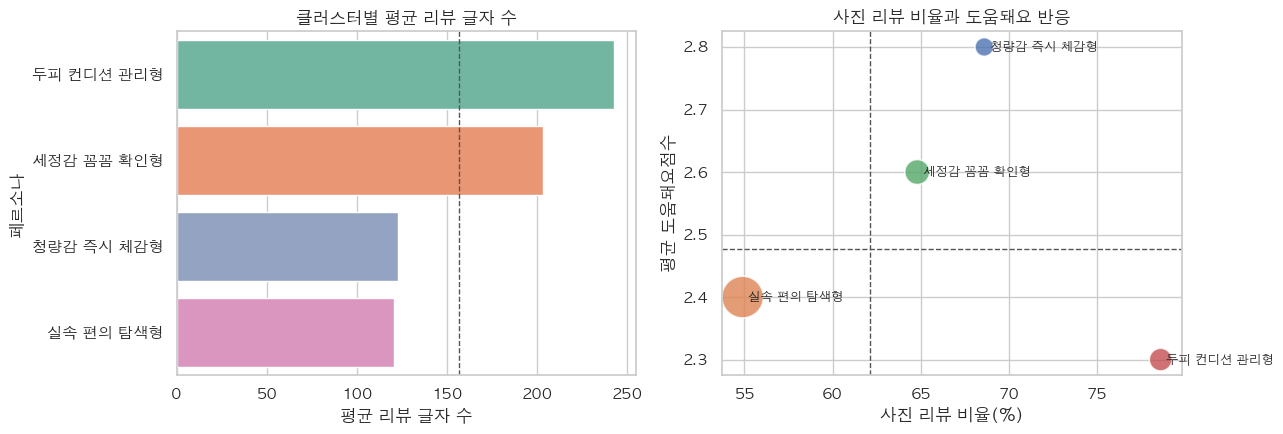

,리뷰군집,페르소나,리뷰수,평균리뷰글자수,평균리뷰단어수,사진리뷰비율,평균도움돼요점수,자주쓰는표현,리뷰형태
0,0,청량감 즉시 체감형,70,122.70,28.90,68.60,2.80,"여름, 거품, 사용하기, 시원한, 있어서, 않고, 구매했",짧은 리뷰형 / 사진 근거형 / 참고도 높음
1,1,실속 편의 탐색형,346,120.60,28.20,54.90,2.40,"사용하기, 냄새, 쓰고, 않고, 드라, 드라이샴푸, 세정력",짧은 리뷰형 / 텍스트 중심형 / 참고도 평균
2,2,세정감 꼼꼼 확인형,125,203.10,47.50,64.80,2.60,"거품, 세정력, 풍성하게, 생각, 샴푸바, 나서, 좋았",긴 리뷰형 / 일반 리뷰형 / 참고도 평균
3,3,두피 컨디션 관리형,103,242.80,56.40,78.60,2.30,"거품, 시원한, 머리카락, 아베다, 이거, 탈모, 세정력",긴 리뷰형 / 사진 근거형 / 참고도 평균


In [27]:
cluster_shape_data = review_data.merge(
    cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사", "대표키워드"]],
    on="리뷰군집",
    how="left",
)

def top_token_text(token_lists, top_n=7):
    counter = Counter(token for tokens in token_lists for token in tokens)
    return ", ".join(token for token, _ in counter.most_common(top_n))

def label_by_range(value, low, high, labels):
    if value <= low:
        return labels[0]
    if value >= high:
        return labels[2]
    return labels[1]

def build_cluster_shape_summary(data):
    summary = (
        data.groupby(["리뷰군집", "페르소나", "주요관심사"], observed=False)
        .agg(
            리뷰수=("리뷰내용", "count"),
            평균리뷰글자수=("리뷰글자수", "mean"),
            중앙리뷰글자수=("리뷰글자수", "median"),
            평균리뷰단어수=("리뷰단어수", "mean"),
            사진리뷰비율=("사진여부", lambda x: x.mean() * 100),
            평균도움돼요점수=("도움돼요점수", "mean"),
            평균평점=("리뷰평점", "mean"),
            자주쓰는표현=("키워드토큰", top_token_text),
        )
        .round(1)
        .reset_index()
    )

    length_mean = review_data["리뷰글자수"].mean()
    photo_mean = review_data["사진여부"].mean() * 100
    help_mean = review_data["도움돼요점수"].mean()

    summary["리뷰형태"] = summary.apply(
        lambda row: " / ".join([
            label_by_range(row["평균리뷰글자수"], length_mean * 0.92, length_mean * 1.08, ["짧은 리뷰형", "평균 길이형", "긴 리뷰형"]),
            label_by_range(row["사진리뷰비율"], photo_mean - 3, photo_mean + 3, ["텍스트 중심형", "일반 리뷰형", "사진 근거형"]),
            label_by_range(row["평균도움돼요점수"], help_mean * 0.92, help_mean * 1.08, ["참고도 낮음", "참고도 평균", "참고도 높음"]),
        ]),
        axis=1,
    )
    return summary, length_mean, photo_mean, help_mean

cluster_shape_summary, overall_review_length, overall_photo_ratio, overall_help_score = build_cluster_shape_summary(cluster_shape_data)
shape_plot = cluster_shape_summary.sort_values("평균리뷰글자수", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=shape_plot, y="페르소나", x="평균리뷰글자수", hue="페르소나", palette="Set2", legend=False, ax=axes[0])
axes[0].axvline(overall_review_length, color="#555555", linestyle="--", linewidth=1)
axes[0].set(title="클러스터별 평균 리뷰 글자 수", xlabel="평균 리뷰 글자 수", ylabel="페르소나")

sns.scatterplot(
    data=cluster_shape_summary,
    x="사진리뷰비율",
    y="평균도움돼요점수",
    size="리뷰수",
    hue="페르소나",
    sizes=(180, 900),
    alpha=0.8,
    ax=axes[1],
)
for _, row in cluster_shape_summary.iterrows():
    axes[1].text(row["사진리뷰비율"] + 0.3, row["평균도움돼요점수"], row["페르소나"], fontsize=9, va="center")
axes[1].axvline(overall_photo_ratio, color="#555555", linestyle="--", linewidth=1)
axes[1].axhline(overall_help_score, color="#555555", linestyle="--", linewidth=1)
axes[1].set(title="사진 리뷰 비율과 도움돼요 반응", xlabel="사진 리뷰 비율(%)", ylabel="평균 도움돼요점수")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

cluster_shape_summary[[
    "리뷰군집", "페르소나", "리뷰수", "평균리뷰글자수", "평균리뷰단어수",
    "사진리뷰비율", "평균도움돼요점수", "자주쓰는표현", "리뷰형태"
]]


<b>클러스터별 리뷰 형태에서 확인한 점</b>

이 시각화는 페르소나별로 리뷰가 얼마나 길고, 사진을 얼마나 붙이며, 다른 소비자에게 얼마나 참고되는지를 보여줍니다. 왼쪽 막대는 평균 리뷰 글자 수이고, 오른쪽 산점도는 사진 리뷰 비율과 도움돼요 반응을 함께 본 것입니다.

`청량감 즉시 체감형`은 평균 리뷰 글자 수가 <b>122.7자</b>로 짧지만 평균 도움돼요점수는 <b>2.83</b>으로 가장 높습니다. 즉 긴 설명보다 `시원하다`, `여름에 좋다`처럼 바로 이해되는 체감 표현이 다른 소비자에게도 잘 먹히는 군집입니다.

`세정감 꼼꼼 확인형`과 `두피 컨디션 관리형`은 각각 <b>203.1자</b>, <b>242.8자</b>로 리뷰가 길게 작성됩니다. 이들은 제품을 단순 체감보다 사용 과정, 세정력, 두피 변화까지 확인하는 편이므로 상세페이지에서는 근거와 사용 맥락을 충분히 보여주는 것이 좋습니다.

`실속 편의 탐색형`은 짧은 텍스트 중심 리뷰가 많고 `사용하기`, `드라이샴푸`, `세정력` 같은 표현이 반복됩니다. 광고 후킹보다는 사용 편의, 구성, 구매 전환 정보를 보강하는 역할에 잘 맞습니다.


#### 군집 간 유사도 확인

4개 군집이 서로 얼마나 다른지 확인하기 위해 군집 중심 벡터 간 코사인 유사도를 계산합니다.  
유사도가 높을수록 두 군집의 리뷰 언어가 비슷하고, 낮을수록 더 분리된 소비자 니즈로 볼 수 있습니다.


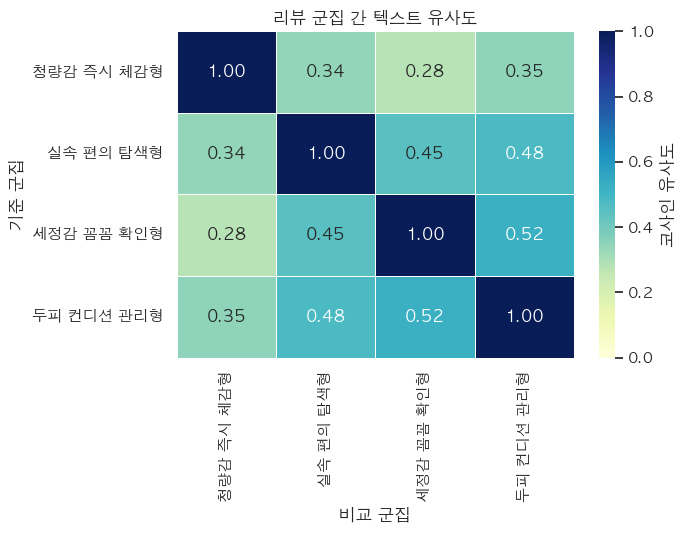

,군집 조합,유사도,공통 대표키워드
0,세정감 꼼꼼 확인형 ↔ 두피 컨디션 관리형,0.52,거품
1,실속 편의 탐색형 ↔ 두피 컨디션 관리형,0.48,사용하기
2,실속 편의 탐색형 ↔ 세정감 꼼꼼 확인형,0.45,세정력
3,청량감 즉시 체감형 ↔ 두피 컨디션 관리형,0.35,"거품, 사용하기, 시원한"
4,청량감 즉시 체감형 ↔ 실속 편의 탐색형,0.34,"사용하기, 있어서"
5,청량감 즉시 체감형 ↔ 세정감 꼼꼼 확인형,0.28,거품


In [28]:
# 군집 간 유사도 확인
cluster_persona_map = cluster_keyword_summary.set_index("리뷰군집")["페르소나"].to_dict()
cluster_label_order = sorted(cluster_persona_map)
cluster_labels = [cluster_persona_map[cluster_id] for cluster_id in cluster_label_order]

cluster_similarity = pd.DataFrame(
    cosine_similarity(kmeans.cluster_centers_),
    index=cluster_labels,
    columns=cluster_labels,
).round(2)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cluster_similarity,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "코사인 유사도"},
)
plt.title("리뷰 군집 간 텍스트 유사도")
plt.xlabel("비교 군집")
plt.ylabel("기준 군집")
plt.tight_layout()
plt.show()

cluster_pair_rows = []
for i, left_id in enumerate(cluster_label_order):
    for right_id in cluster_label_order[i + 1:]:
        left_persona = cluster_persona_map[left_id]
        right_persona = cluster_persona_map[right_id]
        left_terms = set(
            cluster_keyword_summary.loc[
                cluster_keyword_summary["리뷰군집"] == left_id,
                "대표키워드",
            ].iloc[0].split(", ")
        )
        right_terms = set(
            cluster_keyword_summary.loc[
                cluster_keyword_summary["리뷰군집"] == right_id,
                "대표키워드",
            ].iloc[0].split(", ")
        )
        shared_terms = sorted(left_terms & right_terms)
        cluster_pair_rows.append({
            "군집 조합": f"{left_persona} ↔ {right_persona}",
            "유사도": cluster_similarity.loc[left_persona, right_persona],
            "공통 대표키워드": ", ".join(shared_terms) if shared_terms else "없음",
        })

cluster_pair_similarity = (
    pd.DataFrame(cluster_pair_rows)
    .sort_values("유사도", ascending=False)
    .reset_index(drop=True)
)

cluster_pair_similarity


<b>군집 간 유사도에서 확인한 점</b>

유사도 히트맵은 4개 페르소나가 실제로 얼마나 분리되어 있는지 확인하기 위한 표입니다. 대각선은 자기 자신과의 비교라 항상 1이고, 대각선을 제외한 값이 높을수록 두 군집의 리뷰 언어가 비슷합니다.

가장 가까운 조합은 `세정감 꼼꼼 확인형 ↔ 두피 컨디션 관리형`으로, 유사도는 <b>0.52</b>입니다. 두 군집 모두 `거품`, `세정`, `두피 컨디션`처럼 사용 후 체감과 기능 확인에 가까운 언어를 공유합니다. 따라서 상세페이지에서는 세정감과 두피 케어를 완전히 분리하기보다, `개운하게 씻기면서 두피는 편안하게`처럼 함께 묶어 설명하는 편이 자연스럽습니다.

반대로 `청량감 즉시 체감형 ↔ 세정감 꼼꼼 확인형`은 유사도 <b>0.28</b>로 가장 낮습니다. 청량감 군집은 즉각적인 시원함과 후킹 장면에 더 가깝고, 세정감 군집은 사용 과정과 세정력 확인에 더 가깝습니다. 따라서 광고 첫 장면은 `즉각 쿨링`으로 열고, 상세페이지 중간에서 `거품/세정/두피 편안함`을 근거로 보강하는 구성이 적합합니다.

즉 4개 군집은 완전히 다른 시장이라기보다, <b>공통 니즈 위에 강조점이 다른 세그먼트</b>로 보는 것이 좋습니다.


#### 페르소나별 긍정/부정 신호 확인

각 페르소나가 어떤 표현을 만족 포인트로 말하고, 어떤 표현을 불편 포인트로 말하는지 확인합니다.  
같은 쿨링 샴푸 리뷰라도 페르소나에 따라 강조되는 긍정 신호와 방어해야 할 부정 신호가 다를 수 있습니다.


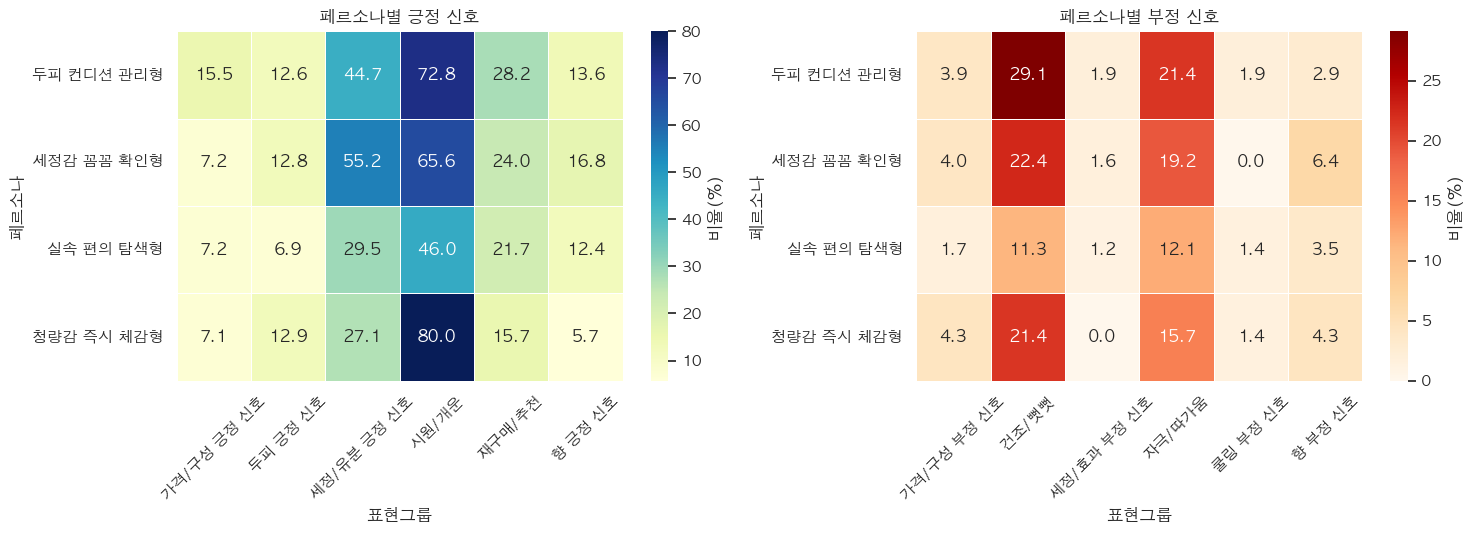

,페르소나,주요 긍정 신호,주요 부정 신호,전체 대비 강한 긍정,전체 대비 강한 부정,메시지 해석
0,두피 컨디션 관리형,"시원/개운(72.8%), 세정/유분 긍정 신호(44.7%)","건조/뻣뻣(29.1%), 자극/따가움(21.4%)",시원/개운(+15.1%p),건조/뻣뻣(+11.7%p),차별화 포인트: 시원/개운 / 안심 문구: 건조/뻣뻣
1,세정감 꼼꼼 확인형,"시원/개운(65.6%), 세정/유분 긍정 신호(55.2%)","건조/뻣뻣(22.4%), 자극/따가움(19.2%)",세정/유분 긍정 신호(+18.6%p),건조/뻣뻣(+5.0%p),차별화 포인트: 세정/유분 긍정 신호 / 안심 문구: 건조/뻣뻣
2,실속 편의 탐색형,"시원/개운(46.0%), 세정/유분 긍정 신호(29.5%)","자극/따가움(12.1%), 건조/뻣뻣(11.3%)",전체 대비 두드러진 긍정 신호 없음,전체 대비 두드러진 부정 신호 없음,차별화 포인트: 카테고리 공통 긍정 메시지 / 안심 문구: 구매 전환 정보 보강
3,청량감 즉시 체감형,"시원/개운(80.0%), 세정/유분 긍정 신호(27.1%)","건조/뻣뻣(21.4%), 자극/따가움(15.7%)",시원/개운(+22.2%p),건조/뻣뻣(+4.0%p),차별화 포인트: 시원/개운 / 안심 문구: 건조/뻣뻣


In [29]:
cluster_persona_data = review_data.merge(
    cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사"]],
    on="리뷰군집",
    how="left",
)

def make_persona_signal_summary(data, pattern_groups, signal_type):
    rows = []
    for label, pattern in pattern_groups.items():
        overall_rate = review_data["정제리뷰"].str.contains(pattern, regex=True, na=False).mean() * 100
        for persona, persona_df in data.groupby("페르소나", observed=False):
            mask = persona_df["정제리뷰"].str.contains(pattern, regex=True, na=False)
            persona_rate = mask.mean() * 100
            rows.append({
                "페르소나": persona,
                "구분": signal_type,
                "표현그룹": label,
                "리뷰수": int(mask.sum()),
                "비율(%)": round(persona_rate, 1),
                "전체대비차이(%p)": round(persona_rate - overall_rate, 1),
            })
    return pd.DataFrame(rows)

persona_signal_summary = pd.concat([
    make_persona_signal_summary(cluster_persona_data, positive_patterns, "긍정 신호"),
    make_persona_signal_summary(cluster_persona_data, negative_patterns, "부정 신호"),
], ignore_index=True)

def signal_matrix(signal_type):
    return persona_signal_summary[persona_signal_summary["구분"] == signal_type].pivot(index="페르소나", columns="표현그룹", values="비율(%)")

positive_persona_matrix = signal_matrix("긍정 신호")
negative_persona_matrix = signal_matrix("부정 신호")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, matrix, title, cmap in [
    (axes[0], positive_persona_matrix, "페르소나별 긍정 신호", "YlGnBu"),
    (axes[1], negative_persona_matrix, "페르소나별 부정 신호", "OrRd"),
]:
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap=cmap, linewidths=0.5, cbar_kws={"label": "비율(%)"}, ax=ax)
    ax.set(title=title, xlabel="표현그룹", ylabel="페르소나")
    ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

def top_signal_text(persona_signals, signal_type, n=2):
    top_rows = persona_signals[persona_signals["구분"] == signal_type].sort_values("비율(%)", ascending=False).head(n)
    return ", ".join(f"{row['표현그룹']}({row['비율(%)']}%)" for _, row in top_rows.iterrows())

def strongest_lift(persona_signals, signal_type, threshold=1.0):
    row = persona_signals[persona_signals["구분"] == signal_type].sort_values("전체대비차이(%p)", ascending=False).iloc[0]
    return row if row["전체대비차이(%p)"] >= threshold else None

def make_persona_signal_playbook(summary):
    rows = []
    for persona, persona_signals in summary.groupby("페르소나", observed=False):
        positive_lift = strongest_lift(persona_signals, "긍정 신호")
        negative_lift = strongest_lift(persona_signals, "부정 신호")
        positive_text = "전체 대비 두드러진 긍정 신호 없음" if positive_lift is None else f"{positive_lift['표현그룹']}({positive_lift['전체대비차이(%p)']:+.1f}%p)"
        negative_text = "전체 대비 두드러진 부정 신호 없음" if negative_lift is None else f"{negative_lift['표현그룹']}({negative_lift['전체대비차이(%p)']:+.1f}%p)"
        message_point = "카테고리 공통 긍정 메시지" if positive_lift is None else positive_lift["표현그룹"]
        risk_point = "구매 전환 정보 보강" if negative_lift is None else negative_lift["표현그룹"]
        rows.append({
            "페르소나": persona,
            "주요 긍정 신호": top_signal_text(persona_signals, "긍정 신호"),
            "주요 부정 신호": top_signal_text(persona_signals, "부정 신호"),
            "전체 대비 강한 긍정": positive_text,
            "전체 대비 강한 부정": negative_text,
            "메시지 해석": f"차별화 포인트: {message_point} / 안심 문구: {risk_point}",
        })
    return pd.DataFrame(rows)

persona_signal_playbook = make_persona_signal_playbook(persona_signal_summary)
persona_signal_playbook


<b>페르소나별 긍정/부정 신호에서 확인한 점</b>

히트맵은 각 페르소나 안에서 긍정/부정 표현이 얼마나 자주 등장했는지 보여줍니다. 색이 진할수록 해당 페르소나가 그 표현을 더 자주 말한다는 뜻입니다.

모든 페르소나에서 `시원/개운`은 공통 긍정 신호입니다. 다만 `청량감 즉시 체감형`은 쿨링 체감이 특히 강하고, `세정감 꼼꼼 확인형`은 세정/유분 신호가 상대적으로 더 뚜렷합니다.

부정 신호는 `건조/뻣뻣`, `자극/따가움`이 중심입니다. 그래서 메시지는 페르소나별로 다르게 잡는 것이 좋습니다. 강한 긍정 신호는 후킹 문구로 쓰고, 강한 부정 신호는 안심 문구로 방어합니다.


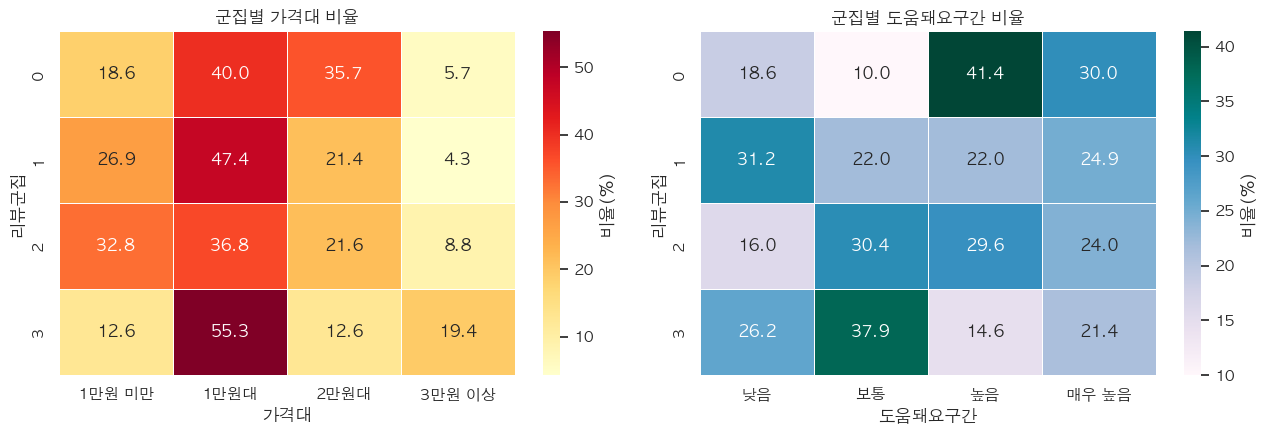

In [30]:
# 군집별 가격대/도움돼요구간 분포 비교
cluster_price_ratio = pd.crosstab(
    review_data["리뷰군집"],
    review_data["가격대"],
    normalize="index",
).mul(100).round(1)

cluster_help_ratio = pd.crosstab(
    review_data["리뷰군집"],
    review_data["도움돼요구간"],
    normalize="index",
).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(
    cluster_price_ratio,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "비율(%)"},
    ax=axes[0],
)
axes[0].set_title("군집별 가격대 비율")
axes[0].set_xlabel("가격대")
axes[0].set_ylabel("리뷰군집")

sns.heatmap(
    cluster_help_ratio,
    annot=True,
    fmt=".1f",
    cmap="PuBuGn",
    linewidths=0.5,
    cbar_kws={"label": "비율(%)"},
    ax=axes[1],
)
axes[1].set_title("군집별 도움돼요구간 비율")
axes[1].set_xlabel("도움돼요구간")
axes[1].set_ylabel("리뷰군집")

plt.tight_layout()
plt.show()


<b>군집별 가격대/도움돼요구간에서 확인한 점</b>

히트맵은 각 군집 안에서 가격대와 도움돼요구간이 어떤 비중으로 나타나는지 보여줍니다. 색이 진할수록 해당 군집에서 그 구간의 비중이 높습니다.

군집별 가격대는 대체로 `1만원대` 중심이지만, 도움돼요구간 분포는 군집마다 다릅니다. 특히 청량감 군집은 도움돼요가 높은 쪽으로 기울어, “시원함을 체감한 리뷰”가 다른 소비자에게도 참고 가치가 높게 작동한 것으로 보입니다.

프로모션에서는 가격대 자체를 세분화하기보다, 같은 1만원대 안에서도 `즉각 쿨링`, `두피 관리`, `실속 구성`처럼 구매 이유를 다르게 제시하는 편이 좋습니다.


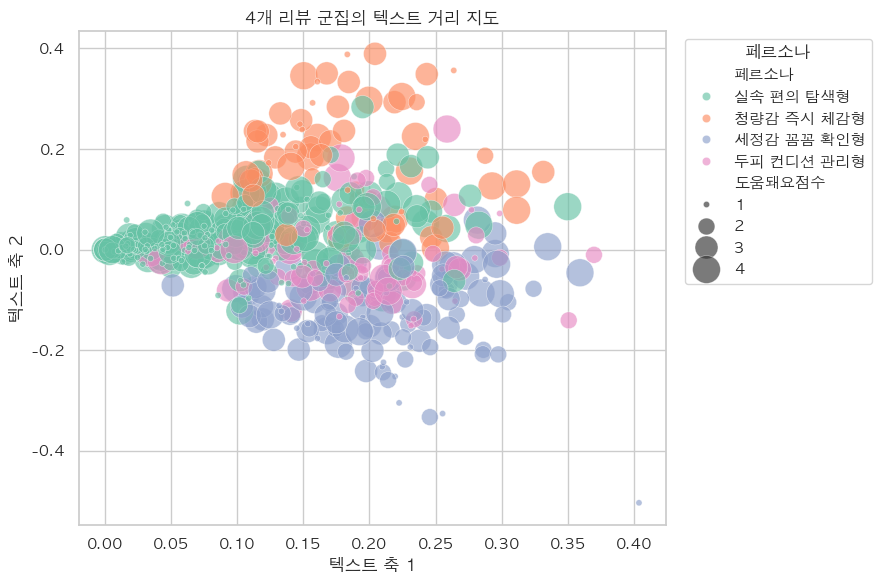

In [31]:
# 리뷰 군집을 2차원으로 축소해 시각화
svd = TruncatedSVD(n_components=2, random_state=42)
cluster_coords = svd.fit_transform(X)
cluster_plot_df = review_data.copy()
cluster_plot_df["축1"] = cluster_coords[:, 0]
cluster_plot_df["축2"] = cluster_coords[:, 1]
cluster_plot_df = cluster_plot_df.merge(
    cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사"]],
    on="리뷰군집",
    how="left",
)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=cluster_plot_df,
    x="축1",
    y="축2",
    hue="페르소나",
    size="도움돼요점수",
    sizes=(20, 400),
    alpha=0.65,
    palette="Set2",
)
plt.title("4개 리뷰 군집의 텍스트 거리 지도")
plt.xlabel("텍스트 축 1")
plt.ylabel("텍스트 축 2")
plt.legend(title="페르소나", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<b>군집 거리 지도에서 확인한 점</b>

2차원 거리 지도에서도 군집이 완전히 따로 떨어지기보다는 일부 겹칩니다. 이는 소비자가 한 리뷰 안에서 `시원함`, `세정감`, `두피`, `향`을 동시에 말한다는 뜻입니다.

따라서 군집은 “완전히 다른 시장”이라기보다, 공통 니즈 위에 강조점이 다른 세그먼트로 보는 편이 적절합니다. 메인 메시지는 `편안하고 오래가는 개운함`으로 묶고, 소재 단계에서 `즉각 쿨링`, `세정감`, `두피 관리`, `실속 구성`을 다르게 변주하는 방식이 좋습니다.


In [32]:
# 군집별 대표 리뷰 샘플
cluster_samples = (
    review_data
    .merge(cluster_keyword_summary[["리뷰군집", "페르소나", "주요관심사"]], on="리뷰군집", how="left")
    .sort_values(["리뷰군집", "도움돼요점수", "리뷰글자수"], ascending=[True, False, False])
    .groupby("리뷰군집")
    .head(1)
    .assign(리뷰요약=lambda df: df["리뷰내용"].str.slice(0, 120) + "...")
    [["리뷰군집", "페르소나", "주요관심사", "브랜드", "가격대", "리뷰평점", "도움돼요구간", "리뷰요약"]]
)

cluster_samples


,리뷰군집,페르소나,주요관심사,브랜드,가격대,리뷰평점,도움돼요구간,리뷰요약
117,0,청량감 즉시 체감형,쿨링/열감,닥터포헤어,2만원대,5,매우 높음,"요즘 날이 점점 더워지면서 두피가 자꾸 땀에 차고 찝찝해지더라고요. 그래서 시원한 느낌을 주는 샴푸를 찾다가 이 제품을 써봤는데, 생각보다 괜찮았어요. 펌핑해서 쓰면 은은한 쿨링감이 확 올라와서 샤워할 때 기..."
300,1,실속 편의 탐색형,가격/구성/편의,려,1만원 미만,5,매우 높음,"요즘 머리카락이 전체적으로 힘이 없고 정수리 쪽 볼륨도 쉽게 죽는 느낌이라 샴푸를 바꿔보려고 이것저것 사용해보는 중인데, 이번에 써본 려 볼륨 모근 강화 샴푸은 생각보다 사용감이 괜찮아서 만족스러웠어요. 특히..."
35,2,세정감 꼼꼼 확인형,세정/거품,온더바디,1만원 미만,5,매우 높음,발 냄새가 신경 쓰이기도 하고 여름이라 땀이 많아져서 한 달 정도 꾸준히 사용해봤어요! 결론부터 말하면 왜 유명한지 알겠는 제품이었어요👣✨ ❤️ 비누향이 진짜 깔끔함 코튼 비누향이라 인위적인 향보다는 막 샤워...
122,3,두피 컨디션 관리형,두피/유분,닥터포헤어,2만원대,5,매우 높음,요즘 너무 덥고 습하고 쓰던 샴푸도 다 써서 여름이니까 쿨링샴푸 쓰려고 구매했는대 오… 생각보다는 조금 아쉬웠어요 냄새는 버물리였나 파스냄새였고 얇은 피부에는 자극 거의 없었는데 두피에 닿자마자 조금의 자극은...


## 7-1. 리뷰 분석 인사이트

앞에서는 리뷰 텍스트를 키워드, 반응 신호, 핵심 메시지 축, 군집 기준으로 나누어 확인했습니다.  
이제 분석 결과를 마케팅 관점에서 다시 묶습니다.

여기서 정리할 내용은 세 가지입니다.

- 어떤 메시지를 가장 앞에 세울 것인가
- 어떤 불안을 미리 방어해야 하는가
- 다음 통합 분석에서 무엇을 추가로 확인할 것인가


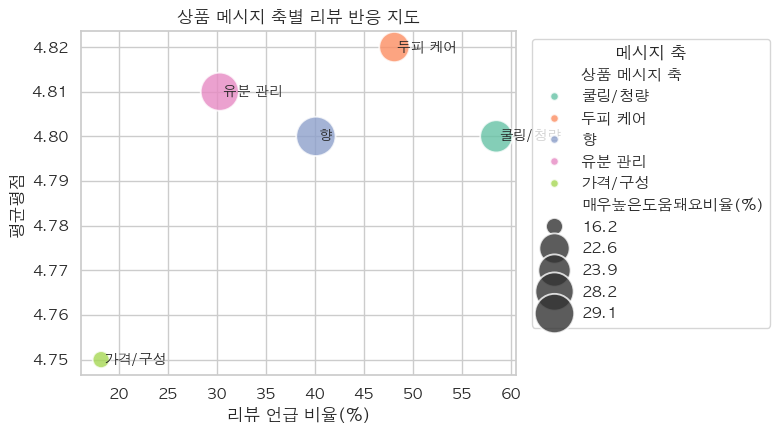

,상품 메시지 축,리뷰 언급 수,리뷰 언급 비율(%),평균평점,낮은평점비율(%),매우높은도움돼요비율(%)
0,쿨링/청량,377,58.50,4.80,4.20,23.90
1,두피 케어,310,48.10,4.82,4.20,22.60
3,향,258,40.10,4.80,4.30,29.10
2,유분 관리,195,30.30,4.81,3.60,28.20
4,가격/구성,117,18.20,4.75,5.10,16.20


In [33]:
# 상품 메시지 축별 리뷰 반응 비교
message_patterns = {
    "쿨링/청량": r"쿨링|시원|청량|개운|상쾌|멘톨|민트",
    "두피 케어": r"두피|가려움|각질|진정|비듬|탈모",
    "유분 관리": r"유분|기름|노세범|떡짐|산뜻|개운",
    "향": r"향|냄새|향기|레몬|자몽|민트|허브",
    "가격/구성": r"가격|가성비|할인|특가|구성|기획|증정|용량|리필|대용량",
}
message_rows = []
for label, pattern in message_patterns.items():
    mask = review_data["정제리뷰"].str.contains(pattern, regex=True, na=False)
    subset = review_data[mask]
    low_rating_ratio = (subset["리뷰평점"] <= 3).mean() * 100 if len(subset) else np.nan
    very_high_help_ratio = (subset["도움돼요구간"] == "매우 높음").mean() * 100 if len(subset) else np.nan
    message_rows.append({
        "상품 메시지 축": label,
        "리뷰 언급 수": len(subset),
        "리뷰 언급 비율(%)": round(mask.mean() * 100, 1),
        "평균평점": round(subset["리뷰평점"].mean(), 2) if len(subset) else np.nan,
        "낮은평점비율(%)": round(low_rating_ratio, 1) if len(subset) else np.nan,
        "매우높은도움돼요비율(%)": round(very_high_help_ratio, 1) if len(subset) else np.nan,
    })

message_review_compare = pd.DataFrame(message_rows).sort_values("리뷰 언급 수", ascending=False)

plt.figure(figsize=(8, 4.5))
sns.scatterplot(
    data=message_review_compare,
    x="리뷰 언급 비율(%)",
    y="평균평점",
    size="매우높은도움돼요비율(%)",
    hue="상품 메시지 축",
    sizes=(150, 800),
    alpha=0.8,
    palette="Set2",
)
for _, row in message_review_compare.iterrows():
    plt.text(row["리뷰 언급 비율(%)"] + 0.3, row["평균평점"], row["상품 메시지 축"], va="center", fontsize=10)
plt.title("상품 메시지 축별 리뷰 반응 지도")
plt.xlabel("리뷰 언급 비율(%)")
plt.ylabel("평균평점")
plt.legend(title="메시지 축", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

message_review_compare.head(5)


<b>상품 메시지와 리뷰 반응을 비교해 확인한 점</b>

산점도는 메시지 축별로 리뷰 언급 비율과 평균 평점을 함께 보여줍니다. 오른쪽에 있을수록 자주 언급된 메시지이고, 위쪽에 있을수록 평점 반응이 좋은 메시지입니다. 버블이 클수록 도움돼요가 높은 리뷰에서 더 많이 등장한 축입니다.

상품 메시지 축에서는 `쿨링/청량`이 <b>58.5%</b>로 가장 많이 언급되고, `두피 케어` <b>48.1%</b>, `향` <b>40.1%</b>가 뒤를 잇습니다.  
다만 `향`은 매우 높은 도움돼요 비율이 <b>29.1%</b>로 높아, 구매 전 참고 포인트로도 강하게 작동합니다.

최종 메시지 구조는 아래처럼 잡는 것이 좋아 보입니다.

- <b>메인 후킹</b>: 쿨링/청량
- <b>신뢰 보강</b>: 두피 케어
- <b>선택 기준</b>: 향
- <b>전환 보조</b>: 가격/구성


### 7-1-1. 마케팅 실행안으로 연결하기

앞에서 확인한 리뷰 신호를 바로 마케팅 의사결정에 쓸 수 있도록, 메시지 축별 우선순위와 페르소나별 활용안을 정리합니다.  
긴 리뷰 원문을 더 펼치기보다 <b>무엇을 앞에 세우고, 무엇을 조심해야 하는지</b>가 보이도록 요약합니다.


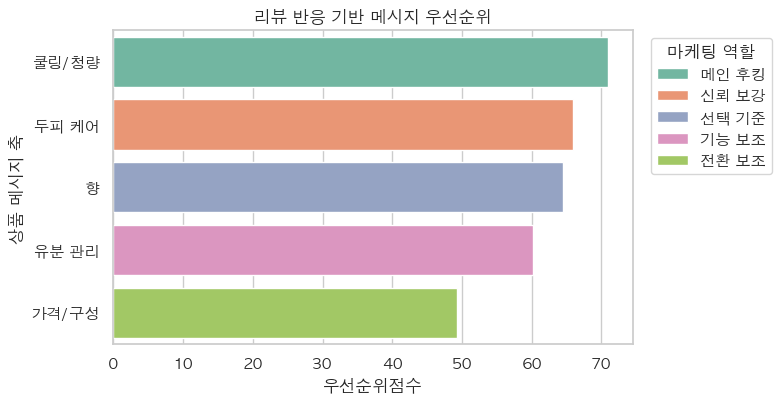

,상품 메시지 축,마케팅 역할,우선순위점수,리뷰 언급 비율(%),평균평점,낮은평점비율(%),권장 액션,주의할 점
0,쿨링/청량,메인 후킹,71.00,58.50,4.80,4.20,상단 카피와 광고 첫 문장에 배치,강한 쿨링만 강조하면 자극/건조 우려가 생길 수 있음
1,두피 케어,신뢰 보강,66.00,48.10,4.82,4.20,자극/건조 걱정을 줄이는 근거 문구로 연결,기능성처럼 보이면 근거 부족 시 신뢰가 약해질 수 있음
3,향,선택 기준,64.50,40.10,4.80,4.30,향 강도와 분위기를 상세페이지에서 구체화,호불호가 커서 강도 표현을 명확히 해야 함
2,유분 관리,기능 보조,60.20,30.30,4.81,3.60,지성 두피/떡짐 고민 소재로 세분화,세정력만 강조하면 뻣뻣함 우려가 생길 수 있음
4,가격/구성,전환 보조,49.30,18.20,4.75,5.10,"기획세트, 리필, 용량 혜택은 구매 버튼 근처에서 보조",메인 후킹보다는 마지막 전환 장치로 쓰는 편이 적절


In [34]:
# 메시지 축별 마케팅 우선순위 계산
message_priority = message_review_compare.copy()
message_priority["우선순위점수"] = (
    message_priority["리뷰 언급 비율(%)"] * 0.45
    + message_priority["매우높은도움돼요비율(%)"] * 0.35
    + message_priority["평균평점"] * 8
    - message_priority["낮은평점비율(%)"] * 0.50
).round(1)
message_role_map = {
    "쿨링/청량": "메인 후킹",
    "두피 케어": "신뢰 보강",
    "향": "선택 기준",
    "유분 관리": "기능 보조",
    "가격/구성": "전환 보조",
}
message_action_map = {
    "쿨링/청량": "상단 카피와 광고 첫 문장에 배치",
    "두피 케어": "자극/건조 걱정을 줄이는 근거 문구로 연결",
    "향": "향 강도와 분위기를 상세페이지에서 구체화",
    "유분 관리": "지성 두피/떡짐 고민 소재로 세분화",
    "가격/구성": "기획세트, 리필, 용량 혜택은 구매 버튼 근처에서 보조",
}
message_risk_map = {
    "쿨링/청량": "강한 쿨링만 강조하면 자극/건조 우려가 생길 수 있음",
    "두피 케어": "기능성처럼 보이면 근거 부족 시 신뢰가 약해질 수 있음",
    "향": "호불호가 커서 강도 표현을 명확히 해야 함",
    "유분 관리": "세정력만 강조하면 뻣뻣함 우려가 생길 수 있음",
    "가격/구성": "메인 후킹보다는 마지막 전환 장치로 쓰는 편이 적절",
}

message_priority["마케팅 역할"] = message_priority["상품 메시지 축"].map(message_role_map)
message_priority["권장 액션"] = message_priority["상품 메시지 축"].map(message_action_map)
message_priority["주의할 점"] = message_priority["상품 메시지 축"].map(message_risk_map)
message_priority = message_priority.sort_values("우선순위점수", ascending=False)

plt.figure(figsize=(8, 4.2))
sns.barplot(
    data=message_priority,
    x="우선순위점수",
    y="상품 메시지 축",
    hue="마케팅 역할",
    dodge=False,
    palette="Set2",
)
plt.title("리뷰 반응 기반 메시지 우선순위")
plt.xlabel("우선순위점수")
plt.ylabel("상품 메시지 축")
plt.legend(title="마케팅 역할", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

message_priority[[
    "상품 메시지 축", "마케팅 역할", "우선순위점수",
    "리뷰 언급 비율(%)", "평균평점", "낮은평점비율(%)",
    "권장 액션", "주의할 점"
]]


<b>메시지 우선순위에서 확인한 점</b>

막대그래프는 언급 비율, 도움돼요 반응, 평균평점, 낮은평점비율을 함께 반영해 메시지 축별 우선순위를 계산한 결과입니다. 점수가 높을수록 앞단 메시지로 쓰기 좋은 축입니다.

`쿨링/청량`은 가장 앞에 세울 메시지입니다. 다만 리뷰에서 함께 보인 장벽이 `자극`, `건조`, `지속성 부족`이므로, 카피는 `강한 쿨링`보다 <b>부담 없이 오래 가는 개운함</b>으로 잡는 편이 좋습니다.

`두피 케어`와 `유분 관리`는 신뢰를 보강하는 근거 메시지로, `향`은 구매 전 선택 기준으로, `가격/구성`은 마지막 전환을 돕는 보조 카드로 쓰는 구조가 자연스럽습니다.


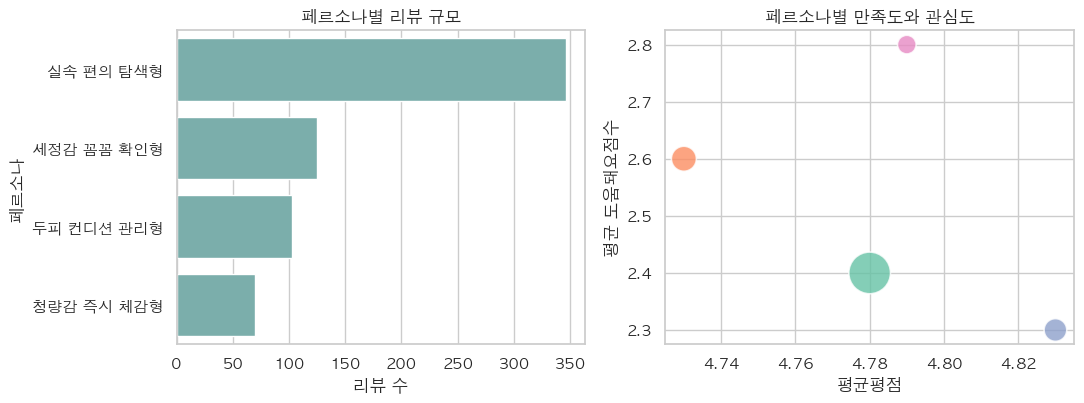

,페르소나,주요관심사,리뷰수,주요가격대,광고 카피 초안,소재 아이디어,주의할 점
1,실속 편의 탐색형,가격/구성/편의,346,1만원대,대용량/리필/기획 구성으로 부담 없이 자주 쓰는 쿨링 루틴,"가격 대비 용량, 리필, 기획세트, 가족 공용 루틴",혜택만 앞세우면 제품력이 약해 보일 수 있어 사용감과 함께 제시
2,세정감 꼼꼼 확인형,세정/거품,125,1만원대,풍성한 거품으로 산뜻하게 씻기고 뻣뻣함은 덜하게,"거품, 세정력, 감은 뒤 머릿결을 보여주는 사용 장면",세정력 강조 시 건조/뻣뻣함 우려를 낮추는 표현 필요
3,두피 컨디션 관리형,두피/유분,103,1만원대,답답한 두피와 유분을 편안하게 관리하는 쿨링 케어,유분/떡짐/가려움 고민 체크리스트와 두피 편안함 근거,진정/탈모 등 기능성 표현은 근거와 범위를 명확히 제시
0,청량감 즉시 체감형,쿨링/열감,70,1만원대,"감는 순간 빠르게 시원하고, 감은 뒤에도 개운하게","운동 후, 퇴근 후, 더운 날 두피 열감 전후 장면",얼얼함만 강조하지 말고 민감 두피 부담을 같이 방어


In [35]:
# 페르소나별 마케팅 플레이북
persona_copy_map = {
    "청량감 즉시 체감형": "감는 순간 빠르게 시원하고, 감은 뒤에도 개운하게",
    "세정감 꼼꼼 확인형": "풍성한 거품으로 산뜻하게 씻기고 뻣뻣함은 덜하게",
    "두피 컨디션 관리형": "답답한 두피와 유분을 편안하게 관리하는 쿨링 케어",
    "향 사용감 민감형": "시원함에 은은한 향을 더한 매일 쓰기 좋은 샴푸",
    "실속 편의 탐색형": "대용량/리필/기획 구성으로 부담 없이 자주 쓰는 쿨링 루틴",
}
persona_creative_map = {
    "청량감 즉시 체감형": "운동 후, 퇴근 후, 더운 날 두피 열감 전후 장면",
    "세정감 꼼꼼 확인형": "거품, 세정력, 감은 뒤 머릿결을 보여주는 사용 장면",
    "두피 컨디션 관리형": "유분/떡짐/가려움 고민 체크리스트와 두피 편안함 근거",
    "향 사용감 민감형": "향 노트, 잔향 강도, 욕실 사용감 비교 카드",
    "실속 편의 탐색형": "가격 대비 용량, 리필, 기획세트, 가족 공용 루틴",
}
persona_guardrail_map = {
    "청량감 즉시 체감형": "얼얼함만 강조하지 말고 민감 두피 부담을 같이 방어",
    "세정감 꼼꼼 확인형": "세정력 강조 시 건조/뻣뻣함 우려를 낮추는 표현 필요",
    "두피 컨디션 관리형": "진정/탈모 등 기능성 표현은 근거와 범위를 명확히 제시",
    "향 사용감 민감형": "향이 강하다는 인상을 줄 수 있어 은은함/잔향 기준 안내",
    "실속 편의 탐색형": "혜택만 앞세우면 제품력이 약해 보일 수 있어 사용감과 함께 제시",
}
persona_playbook = cluster_keyword_summary[[
    "페르소나", "주요관심사", "리뷰수", "평균평점", "평균도움돼요점수", "주요가격대", "메시지 방향"
]].copy()
persona_playbook["광고 카피 초안"] = persona_playbook["페르소나"].map(persona_copy_map)
persona_playbook["소재 아이디어"] = persona_playbook["페르소나"].map(persona_creative_map)
persona_playbook["주의할 점"] = persona_playbook["페르소나"].map(persona_guardrail_map)
persona_playbook = persona_playbook.sort_values("리뷰수", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(data=persona_playbook, x="리뷰수", y="페르소나", color="#72B7B2", ax=axes[0])
axes[0].set_title("페르소나별 리뷰 규모")
axes[0].set_xlabel("리뷰 수")
axes[0].set_ylabel("페르소나")

sns.scatterplot(
    data=persona_playbook,
    x="평균평점",
    y="평균도움돼요점수",
    size="리뷰수",
    hue="페르소나",
    sizes=(180, 900),
    alpha=0.8,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("페르소나별 만족도와 관심도")
axes[1].set_xlabel("평균평점")
axes[1].set_ylabel("평균 도움돼요점수")
axes[1].legend_.remove()
plt.tight_layout()
plt.show()

persona_playbook[[
    "페르소나", "주요관심사", "리뷰수", "주요가격대",
    "광고 카피 초안", "소재 아이디어", "주의할 점"
]]


<b>페르소나별 실행안에서 확인한 점</b>

왼쪽 막대그래프는 페르소나별 리뷰 규모를, 오른쪽 산점도는 평균 평점과 도움돼요 반응을 함께 보여줍니다. 규모가 큰 군집은 넓은 타겟으로, 도움돼요 반응이 높은 군집은 광고 후킹 소재로 보기 좋습니다.

가장 큰 군집은 `실속 편의 탐색형`이지만, 광고 첫 후킹은 규모만 보고 정하기보다 도움돼요 반응과 메시지 선명도를 함께 봐야 합니다.

따라서 광고는 `청량감 즉시 체감형`처럼 한눈에 이해되는 장면으로 시작하고, 상세페이지에서는 `실속/세정/두피` 근거를 차례로 설득하는 구조가 좋아 보입니다.


In [36]:
# 최종 마케팅 브리프
marketing_brief = pd.DataFrame({
    "의사결정 영역": [
        "제품 컨셉",
        "메인 카피",
        "상세페이지 구조",
        "광고 소재",
        "방어해야 할 리스크",
    ],
    "권장 방향": [
        "민감 두피도 부담 없이 쓰는 지속 쿨링 샴푸",
        "강한 쿨링보다 오래 가는 두피 개운함",
        "쿨링 체감 -> 두피/유분 케어 근거 -> 향/사용감 -> 가격/구성 혜택",
        "운동 후, 퇴근 후, 여름철 열감처럼 즉시 체감 장면을 전면 배치",
        "자극, 건조함, 향 호불호, 쿨링 지속성 부족",
    ],
    "분석 근거": [
        "쿨링 언급은 높지만 민감/자극 회피 신호도 함께 큼",
        "강한 쿨링 긍정보다 지속/편안함 니즈가 마케팅 장벽을 더 잘 해결",
        "쿨링/두피/향/가격 메시지가 서로 다른 역할을 가짐",
        "청량감 군집은 규모보다 후킹 소재로서 선명도가 높음",
        "부정 신호가 구매 망설임으로 이어질 수 있어 선제 설명 필요",
    ],
})

marketing_brief


,의사결정 영역,권장 방향,분석 근거
0,제품 컨셉,민감 두피도 부담 없이 쓰는 지속 쿨링 샴푸,쿨링 언급은 높지만 민감/자극 회피 신호도 함께 큼
1,메인 카피,강한 쿨링보다 오래 가는 두피 개운함,강한 쿨링 긍정보다 지속/편안함 니즈가 마케팅 장벽을 더 잘 해결
2,상세페이지 구조,쿨링 체감 -> 두피/유분 케어 근거 -> 향/사용감 -> 가격/구성 혜택,쿨링/두피/향/가격 메시지가 서로 다른 역할을 가짐
3,광고 소재,"운동 후, 퇴근 후, 여름철 열감처럼 즉시 체감 장면을 전면 배치",청량감 군집은 규모보다 후킹 소재로서 선명도가 높음
4,방어해야 할 리스크,"자극, 건조함, 향 호불호, 쿨링 지속성 부족",부정 신호가 구매 망설임으로 이어질 수 있어 선제 설명 필요


In [37]:
# 긍정/부정 반응 포인트와 다음 질문 정리
review_text_insight_summary = pd.DataFrame({
    "인사이트 축": [
        "상품 메시지와 리뷰 반응",
        "긍정 반응 포인트",
        "부정 반응 포인트",
        "타겟/페르소나 활용",
        "통합 인사이트로 넘길 질문",
    ],
    "정리": [
        "상품명에서 강조된 쿨링/두피/유분/향/가격 메시지가 실제 리뷰에서 얼마나 언급되는지 비교한다.",
        "시원함, 개운함, 향, 세정감, 가성비/구성처럼 긍정 신호로 읽히는 표현을 확인한다.",
        "자극, 건조함, 향 강도, 쿨링 부족, 효과 체감 부족, 가격/용량 아쉬움이 어떤 조건에서 나타나는지 확인한다.",
        "4개 군집을 소비자 세그먼트로 보고, 각 군집의 대표 키워드·가격대·도움돼요구간을 메시지 설계에 연결한다.",
        "어떤 메시지는 구매 전 기대를 만들고, 어떤 메시지는 사용 후 긍정/부정 반응으로 바뀌는가?",
    ],
    "다음 분석에서 볼 것": [
        "상품명 키워드 비중과 리뷰 언급 비중의 차이",
        "평점이 높은 리뷰와 도움돼요가 높은 리뷰의 공통 표현",
        "낮은 평점 리뷰와 특정 가격대/브랜드/군집의 연결",
        "군집별 페르소나에 맞는 상세페이지 메시지, 광고 타겟, 프로모션 방향",
        "상품 포지셔닝, 리뷰 반응, 가격대, 브랜드 메시지를 하나의 표로 통합",
    ],
})

review_text_insight_summary


,인사이트 축,정리,다음 분석에서 볼 것
0,상품 메시지와 리뷰 반응,상품명에서 강조된 쿨링/두피/유분/향/가격 메시지가 실제 리뷰에서 얼마나 언급되는지 비교한다.,상품명 키워드 비중과 리뷰 언급 비중의 차이
1,긍정 반응 포인트,"시원함, 개운함, 향, 세정감, 가성비/구성처럼 긍정 신호로 읽히는 표현을 확인한다.",평점이 높은 리뷰와 도움돼요가 높은 리뷰의 공통 표현
2,부정 반응 포인트,"자극, 건조함, 향 강도, 쿨링 부족, 효과 체감 부족, 가격/용량 아쉬움이 어떤 조건에서 나타나는지 확인한다.",낮은 평점 리뷰와 특정 가격대/브랜드/군집의 연결
3,타겟/페르소나 활용,"4개 군집을 소비자 세그먼트로 보고, 각 군집의 대표 키워드·가격대·도움돼요구간을 메시지 설계에 연결한다.","군집별 페르소나에 맞는 상세페이지 메시지, 광고 타겟, 프로모션 방향"
4,통합 인사이트로 넘길 질문,"어떤 메시지는 구매 전 기대를 만들고, 어떤 메시지는 사용 후 긍정/부정 반응으로 바뀌는가?","상품 포지셔닝, 리뷰 반응, 가격대, 브랜드 메시지를 하나의 표로 통합"


### 7-1-2. 리뷰 텍스트 분석에서 확인한 점

핵심은 <b>쿨링 니즈는 분명하지만, 구매 장벽은 자극/건조/지속성 불안에 있다</b>는 점입니다.

- 처음 가설은 <b>“여름이면 쿨링 샴푸를 더 많이 찾을 것이다”</b>였습니다. 하지만 리뷰를 보면 문제는 쿨링 니즈가 없는 것이 아니라, 쿨링 제품을 쓸 때 생길 수 있는 <b>민감함/자극/건조함/지속성 부족</b>에 대한 걱정이었습니다.
- 정제 리뷰 <b>644건</b> 기준으로 `쿨링/시원` 언급은 <b>58.5%</b>로 높았습니다. 쿨링은 중요한 구매/사용 언어입니다.
- 다만 `강한 쿨링 긍정`은 <b>9.5%</b>로 제한적이었고, `민감/자극 회피` 신호는 <b>27.8%</b>로 나타났습니다.
- 전체 키워드에서는 <b>거품</b>, <b>세정력</b>, <b>사용하기</b>, <b>시원한</b>이 강했습니다. 소비자는 쿨링감뿐 아니라 실제 사용 과정의 <b>거품/세정/편의성</b>까지 함께 평가했습니다.
- 리뷰 군집은 <b>실속 편의 탐색형</b>, <b>세정감 꼼꼼 확인형</b>, <b>두피 컨디션 관리형</b>, <b>청량감 즉시 체감형</b> 4개로 나뉘었습니다. 다만 군집 간 유사도와 거리 지도를 함께 보면 완전히 분리된 집단이라기보다, 공통 니즈 위에 강조점이 다른 세그먼트에 가깝습니다.


### 7-1-3. 리뷰 텍스트 분석에서 나온 마케팅 결론

리뷰 반응을 기준으로 보면 쿨링 샴푸의 메인 후킹은 여전히 <b>쿨링/청량</b>이 맞습니다.  
하지만 “강한 쿨링”만 말하면 소비자가 걱정하는 `자극`, `건조`, `두피 민감`, `지속성 부족`을 해결하지 못합니다.

따라서 신제품 방향은 아래처럼 잡는 것이 좋아 보입니다.

| 구분 | 방향 |
|---|---|
| 제품 컨셉 | 민감 두피도 부담 없이 쓰는 지속 쿨링 샴푸 |
| 핵심 사용감 | 처음에는 빠르게 시원하고, 감은 뒤에는 오래 개운하게 |
| 기능 보강 | 쿨링감 + 두피 진정 + 유분/세정 케어 |
| 리스크 방어 | 자극감, 건조함, 향 호불호를 줄이는 순한 사용감 |

광고 메시지는 `얼얼한 쿨링`보다 아래 방향이 더 설득력 있어 보입니다.

- `오래 가는 두피 개운함`
- `민감한 두피도 부담 없는 쿨링감`
- `여름만이 아니라 답답한 두피가 필요한 순간마다`
- `시원하지만 뻣뻣하지 않은 세정감`

즉 결론은 <b>“쿨링을 더 세게”가 아니라, “쿨링을 더 편안하고 오래가게” 만드는 것</b>입니다.


### 7-1-4. 리뷰 텍스트 분석만으로는 부족했던 점

리뷰 텍스트만으로는 소비자가 어떤 표현에 반응했는지는 볼 수 있지만, 어떤 상품 스펙이나 메시지가 그 반응을 만들었는지는 아직 완전히 판단하기 어렵습니다.

추가로 확인해야 할 부분은 아래와 같습니다.

- `쿨링 지속성`을 실제 제품 성분, 사용법, 제형과 연결해서 설명할 수 있는지
- `민감/자극 회피` 신호가 특정 브랜드, 가격대, 기능성 제품에 몰려 있는지
- 낮은 평점 리뷰에서 나온 `건조`, `자극`, `향 호불호`, `쿨링 부족`이 어떤 상품 유형에서 반복되는지
- 리뷰 언급 비율이 낮은 `가격/구성`이 실제 구매 전환에서는 어떤 역할을 하는지
- 군집별 페르소나가 실제 상품 유형과 연결되는지


### 7-1-5. 다음 통합 인사이트 분석으로 이어질 질문

다음 분석에서는 상품 데이터와 리뷰 텍스트 데이터를 함께 묶어 아래 질문을 확인합니다.

- 상품명에서 강조한 <b>쿨링/청량감</b>은 실제 리뷰에서 긍정 반응으로 이어지는가, 아니면 자극/건조 리스크와 함께 나타나는가?
- `오래 가는 쿨링감`을 말할 수 있는 제품은 어떤 특징을 가지고 있는가?
- <b>두피 케어</b>, <b>유분 관리</b>, <b>탈모 기능성</b> 소구는 리뷰 본문에서도 실제 사용 경험으로 확인되는가?
- 브랜드별로 잘 맞는 메시지가 다른가?
- 가격대별로 소비자가 기대하는 포인트가 다른가?
- 4개 페르소나별로 신제품 컨셉, 상세페이지 문구, 광고 카피, 리뷰 소재를 어떻게 다르게 설계할 수 있는가?
